## NBA Player Minutes Predictor - XGBoost Quantile
**- Owner:** Alex

**- Status:** Exploration only - not a production pipeline yet

**- Last Updated:** 9/28/26

### Question

**How accurately can we predict an NBA player's minutes in their next game,
and can XGBoost beat a simple rolling average of recent minutes and LightGBM?**

### Decision Criteria
**- Primary metric:** q50 pinball (minutes). Lower is better.

**- Secondary metric:** 80% interval (q10–q90) and 90% interval (q05–q95) coverage near their targets

**- Serving threshold:** none yet — exploration only

**- Guardrail:** no quantile crossing; 2025-26 is scored once and never used to tune

### Data Contract
**- Data:** nba_api, rotowire, and basketball reference

**- Unit:** one row per player-game (`game_id`, `player_id`)

**- Features:** known 1 hour before tip-off (prior minutes, role, schedule, market)

**- Label:** minutes played (`minutes` > 0)

**- Split:** chronological; train on 2023-24 and 2024-25, hold out 2025-26

### Setup and Configurations

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

def _repo_root() -> Path:
    starts = []
    nb = globals().get("__vsc_ipynb_file__")
    if nb:
        starts.append(Path(nb).resolve().parent)
    starts.append(Path.cwd().resolve())
    for start in starts:
        for candidate in (start, *start.parents):
            if (candidate / "pyproject.toml").is_file():
                return candidate
    raise RuntimeError("could not find repo root (pyproject.toml)")

ROOT = _repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features.minutes import (
    TIER1_MINUTES_FEATURES,
    add_minutes_features,
)

In [2]:
# ── Prop-specific config (NBA MIN) ────────────────────────────────────────────

HOLDOUT_SEASON = "2025-26"
ID_COLS = ["game_id", "player_id", "season_year", "player_name", "game_date"]
TARGET_COL = "minutes"
ROLE_COL = "starting"
SEED = 42

QUANTILES = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95]

XGB_PARAMS = dict(
    objective="reg:quantileerror",
    n_estimators=1198,
    max_depth=4,
    learning_rate=0.10831429032170246,
    subsample=0.7978199709619458,
    colsample_bytree=0.8074992328271139,
    reg_alpha=4.019094324629617,
    reg_lambda=0.7852113626147341,
    min_child_weight=8,
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=50,
    seed=SEED
)
# Filled by the locked tune_lgb_quantile run. Do not hand-edit.
LGB_PARAMS = dict(
    objective='quantile',
    n_jobs=-1,
    random_state=42,
    verbose=-1,
    bagging_freq=1,
    early_stopping_rounds=50,
    n_estimators=1332,
    num_leaves=39,
    max_depth=8,
    learning_rate=0.010913251568080208,
    subsample=0.6164222829891212,
    colsample_bytree=0.6536603998011501,
    reg_alpha=0.004696562896252921,
    reg_lambda=0.11261493876779227,
    min_child_samples=30,
)


MIN_TIERS = {
    "<15 min": lambda a: a < 15,
    "15-24 min": lambda a: (a >= 15) & (a < 24),
    "24-31 min": lambda a: (a >= 24) & (a < 31),
    "31+ min": lambda a: a >= 31,
}

ARTIFACT_STEM = "min_nba_model"

# ── Shared train/eval helpers ─────────────────────────────────────────────────
from models.shared.splits import prepare_splits
from models.shared.train import (
    evaluate_holdout,
    fit_quantile_lightgbm,
    run_timeseries_cv,
    run_walk_forward,
    tune_lgb_quantile,
)
from models.shared.analysis import run_feature_ablation, analyze_correlations
from models.shared.artifacts import save_model_bundle, load_model_bundle, predict_quantiles
from models.shared.metrics import interval_coverage, pinball_50, pinball_loss


### Data

In [3]:
s20 = pd.read_parquet(ROOT / "data/silver/nba/2019-20/regular_season/player_gamelogs.parquet")
s21 = pd.read_parquet(ROOT / "data/silver/nba/2020-21/regular_season/player_gamelogs.parquet")
s22 = pd.read_parquet(ROOT / "data/silver/nba/2021-22/regular_season/player_gamelogs.parquet")
s23 = pd.read_parquet(ROOT / "data/silver/nba/2022-23/regular_season/player_gamelogs.parquet")
s24 = pd.read_parquet(ROOT / "data/silver/nba/2023-24/regular_season/player_gamelogs.parquet")
s25 = pd.read_parquet(ROOT / "data/silver/nba/2024-25/regular_season/player_gamelogs.parquet")
s26 = pd.read_parquet(ROOT / "data/silver/nba/2025-26/regular_season/player_gamelogs.parquet")
df = pd.concat([s20, s21, s22, s23, s24, s25, s26])
df['starting'] = (
    df['start_position'].astype('string').str.strip().isin(['G', 'F', 'C']).astype(int)
)
df.sample(5)

,season_year,player_id,player_name,nickname,team_id,team_abbreviation,team_name,game_id,game_date,matchup,...,opp_pace,opp_pace_per40,opp_poss,opp_pie,season_type,pos,game_total,team_spread,player_team_spread,starting
23449,2024-25,1629726,Garrison Mathews,Garrison,1610612737,ATL,Atlanta Hawks,0022400185,2024-11-08T00:00:00,ATL @ DET,...,106.50,88.75,106,0.506,Regular Season,SG,227.5,-2.0,2.0,0
11916,2025-26,1642852,Derik Queen,Derik,1610612740,NOP,New Orleans Pelicans,0022500654,2026-01-25T00:00:00,NOP @ SAS,...,95.50,79.58,95,0.466,Regular Season,C,240.0,-11.5,11.5,1
12517,2024-25,1630538,Bones Hyland,Bones,1610612746,LAC,LA Clippers,0022400620,2025-01-22T00:00:00,LAC vs. BOS,...,96.91,80.75,108,0.509,Regular Season,PG,216.5,12.0,12.0,0
7278,2023-24,1630529,Herbert Jones,Herbert,1610612740,NOP,New Orleans Pelicans,0022300863,2024-03-01T00:00:00,NOP vs. IND,...,102.00,85.00,102,0.380,Regular Season,SF,238.5,-5.5,-5.5,1
15598,2023-24,1629014,Anfernee Simons,Anfernee,1610612757,POR,Portland Trail Blazers,0022300472,2024-01-03T00:00:00,POR @ DAL,...,104.00,86.67,104,0.703,Regular Season,SG,239.0,-11.0,11.0,1


In [4]:
# Data Quality Checks
print(f"Number of rows : {len(df)}")
print(f"Number of columns: {len(df.columns)}")
print(f"Number of Unique Players: {df['player_id'].nunique()}")
print(f"Number of Unique Games: {df['game_id'].nunique()}")
print(f"Total number of duplicates: {df.duplicated(subset=['game_id', 'player_id']).sum()}")
print(f"Missing Labels: {df['minutes'].isna().sum()}")
print(f"Missing Start Position: {df['starting'].isna().sum()}")
print(f"Median Minutes: {df['minutes'].median()}")
print(f"Mean Minutes: {df['minutes'].mean().round(3)}")
print(f"Max Minutes: {df['minutes'].max().round(3)}")
print(f"Standard Deviation of Minutes: {df['minutes'].std().round(3)}")
print(f"Skewness of Minutes: {df['minutes'].skew().round(3)}")
print(f"Kurtosis of Minutes: {df['minutes'].kurt().round(3)}")
print(f"Percentage of players 20+ minutes: {round(df[df['minutes'] >= 20]['player_id'].nunique() / df['player_id'].nunique(), 3) * 100}%")
print(f"Percentage of players 30+ minutes: {round(df[df['minutes'] >= 30]['player_id'].nunique() / df['player_id'].nunique(), 3) * 100}%")
print(f"Percentage of players 40+ minutes: {round(df[df['minutes'] >= 40]['player_id'].nunique() / df['player_id'].nunique(), 1) * 100}%")

Number of rows : 176738
Number of columns: 190
Number of Unique Players: 1172
Number of Unique Games: 8289
Total number of duplicates: 0
Missing Labels: 0
Missing Start Position: 0
Median Minutes: 23.64
Mean Minutes: 22.65
Max Minutes: 56.517
Standard Deviation of Minutes: 10.67
Skewness of Minutes: -0.279
Kurtosis of Minutes: -0.805
Percentage of players 20+ minutes: 86.4%
Percentage of players 30+ minutes: 73.2%
Percentage of players 40+ minutes: 40.0%


### Features

**IDEAS:** 
1. pts/100 possessions with star absent vs active
2. USG% with start absent vs active
3. FGA/36 with star absent vs active

For EWMA use a = 0.05
look into using a random forest and bayesian hierarchical regression model alongside your xgboost and linear models 

In [5]:
# adds features to the dataset
df = add_minutes_features(df)

In [6]:
# features that should be added to the dataset
  
# create starters available features
N = 10  # lookback window in team games

d = df.copy()
d['game_date'] = pd.to_datetime(d['game_date'])
d['mins'] = d['minutes']
d['started'] = d['starting'].fillna(0).astype(int)
d['played'] = (d['mins'] > 0).astype(int)

# 1. Team schedule with a team-game index per season
sched = (d[['season_year', 'team_id', 'game_id', 'game_date']]
         .drop_duplicates(['team_id', 'game_id'])
         .sort_values(['team_id', 'game_date']))
sched['tg_num'] = sched.groupby(['season_year', 'team_id']).cumcount()

# 2. Full grid: every player on the team x every team game during their tenure
tenure = (d.groupby(['season_year', 'team_id', 'player_id'])['game_date']
           .agg(first='min', last='max').reset_index())
grid = tenure.merge(sched, on=['season_year', 'team_id'])
grid = grid[(grid['game_date'] >= grid['first']) & (grid['game_date'] <= grid['last'])]
grid = grid.merge(d[['team_id', 'game_id', 'player_id', 'mins', 'started', 'played']],
                  on=['team_id', 'game_id', 'player_id'], how='left')
grid[['mins', 'started', 'played']] = grid[['mins', 'started', 'played']].fillna(0)
grid = grid.sort_values(['season_year', 'team_id', 'player_id', 'tg_num'])

# 3. Pre-game history (shift(1) = only prior games)
g = grid.groupby(['season_year', 'team_id', 'player_id'])
grid['starts_lN'] = g['started'].transform(
    lambda s: s.shift(1).rolling(N, min_periods=1).sum())
grid['mins_played'] = grid['mins'].where(grid['played'] == 1)   # ignore DNPs
grid['min_avg_lN'] = g['mins_played'].transform(
    lambda s: s.shift(1).rolling(N, min_periods=1).mean())

# 4. Rank within each team-game: most starts, tie-break on minutes
grid = grid.sort_values(['team_id', 'game_id', 'starts_lN', 'min_avg_lN'],
                        ascending=[True, True, False, False])
grid['starter_rank'] = grid.groupby(['team_id', 'game_id']).cumcount() + 1
grid['is_main_starter'] = ((grid['starter_rank'] <= 5) & (grid['starts_lN'] > 0)).astype(int)

main = grid[grid['is_main_starter'] == 1]

# 5. Team-game features
team_feats = (main.assign(missing_min=main['min_avg_lN'].where(main['played'] == 0, 0))
                  .groupby(['team_id', 'game_id'])
                  .agg(main_starters_playing=('played', 'sum'),
                       main_starters_defined=('player_id', 'size'),
                       starter_min_missing=('missing_min', 'sum'))
                  .reset_index())

# 6. Merge back, excluding the player's own absence (avoids target leakage)
df = (df.merge(team_feats, on=['team_id', 'game_id'], how='left')
        .merge(grid[['team_id', 'game_id', 'player_id', 'is_main_starter', 'min_avg_lN', 'starter_rank']],
               on=['team_id', 'game_id', 'player_id'], how='left'))

own_missing = np.where((df['is_main_starter'] == 1) & (df['minutes'].fillna(0) == 0),
                       df['min_avg_lN'].fillna(0), 0)
df['starter_min_missing_teammates'] = df['starter_min_missing'] - own_missing
df['main_starters_out'] = df['main_starters_defined'] - df['main_starters_playing']

In [14]:
# selected features to use in the model
MIN_FEATURES = [
    "starting",
    "min_ewm_hl_10",
    "min_vol_10",
    "min_lag_1",
    "season_min_mean",
    "current_team_min_mean",
    "min10_x_expected_possessions",
    "season_start_rate",
    "start_rate_10",
    "player_days_since_appearance",
    "player_appearances_prev_7d",
    "prior_season_min_mean",
    "start_rate_x_abs_spread",
    "implied_team_total",
    "min_mean_3_minus_10",
    "starter_min_missing_teammates",
    "main_starters_out",
    "min_avg_lN",
    "starter_rank",
    "is_main_starter",
    "min_p20_20",
    "min_p80_20",
    "min_p80_minus_p20_20",
    "min_trim_mean_20",
    "min_floor_10",
    "min_ceiling_10",
    "min_span_10",
    "min_lag_outside_10",
    "season_min_vol",
    "min_unstable",
]
 
print(f"Number of features: {len(MIN_FEATURES)}")
print(f"Number of nulls: {df[MIN_FEATURES].isna().sum().sum()}")

Number of features: 30
Number of nulls: 136372


### Train/validation/test design
**- Train:** 2019-10-22 → 2025-04-13 (2019-20, 2020-21, 2021-22, 2022-23, 2023-24, 2024-25). Each fold fits on its past dates. The 2025-26 fit uses the first 90% of this pool.

**- Validation:** Inside the train pool only. Optuna picks hyperparameters on a 3-fold TimeSeriesSplit by q50 pinball. Walk-forward then scores 4 non-overlapping blocks, each the next 10% of game dates after a 50% training window, stepping forward 10%. Those windows end 2024-11-25, 2024-12-31, 2025-02-01, and 2025-03-10. The first half of train dates, and dates after 2025-03-10, are never scored.

**- Test:** 2025-10-21 → 2026-04-12 (2025-26). Scored once, after features and hyperparameters are locked on the validation folds.

**- Split type:** Chronological. Walk-forward keeps every row from a game_date on one side. TimeSeriesSplit cuts by row index, so one slate can straddle a fold.

**- Embargo:** None. The next game date after the last training date is validation. The gap from 2025-04-13 to 2025-10-21 is the offseason, not a purge.

**- Important:** 2025-26 is not used to choose features, hyperparameters, or early-stopping rounds. Walk-forward still early-stops on the rows it scores. The holdout fit early-stops on the last 10% of the train pool and never puts 2025-26 in eval_set.

In [15]:
df = df[(df['minutes'] > 0)]
print(f"After filtering minutes: {df[MIN_FEATURES].shape[0]} rows")

splits = prepare_splits(
    df,
    holdout_season=HOLDOUT_SEASON,
    features=MIN_FEATURES,
    target_col=TARGET_COL,
    id_cols=ID_COLS,
    role_col=ROLE_COL,
    extra_keep=["minutes", "min_ewm_hl_10"],
)
ppm_df = splits["ppm_df"]
ppm_holdout = splits["ppm_holdout"]
X = splits["X"]
y = splits["y"]

After filtering minutes: 176710 rows
Train pool (excl. 2025-26) : 150,062 rows
Holdout   (2025-26)        : 26,648 rows
Date range (train)   : 2019-10-22 → 2025-04-13
Date range (holdout) : 2025-10-21 → 2026-04-12


### EDA

Appearance rows: 176,710
Features with a null: 26 / 30
Rows with any null feature: 52,499 (29.7%)


,n_missing,pct_missing
prior_season_min_mean,43373,24.54
season_min_vol,7814,4.42
min_unstable,7814,4.42
min_avg_lN,5947,3.37
min_p20_20,5629,3.19
min_p80_20,5629,3.19
min_p80_minus_p20_20,5629,3.19
min_trim_mean_20,5629,3.19
start_rate_x_abs_spread,5351,3.03
implied_team_total,4706,2.66


,prior_season_min_mean,season_min_vol,min_unstable,min_avg_lN,min_p20_20,min_p80_20,min_p80_minus_p20_20,min_trim_mean_20,start_rate_x_abs_spread,implied_team_total,...,main_starters_out,min_vol_10,min_floor_10,min_ceiling_10,min_span_10,min10_x_expected_possessions,min_ewm_hl_10,min_lag_1,start_rate_10,min_mean_3_minus_10
season_year,,,,,,,,,,,,,,,,,,,,,
2019-20,100.0,4.7,4.7,3.5,11.5,11.5,11.5,11.5,10.0,7.7,...,1.4,4.7,4.7,4.7,4.7,2.4,2.4,2.4,2.4,2.4
2020-21,13.9,4.7,4.7,3.4,2.3,2.3,2.3,2.3,0.5,0.0,...,1.4,0.9,0.9,0.9,0.9,0.5,0.5,0.5,0.5,0.5
2021-22,14.2,4.6,4.6,3.5,2.3,2.3,2.3,2.3,2.8,4.1,...,1.3,1.0,1.0,1.0,1.0,0.5,0.5,0.5,0.5,0.5
2022-23,12.6,4.1,4.1,3.2,1.6,1.6,1.6,1.6,1.0,0.7,...,1.3,0.7,0.7,0.7,0.7,0.3,0.3,0.3,0.3,0.3
2023-24,12.7,4.3,4.3,3.4,1.8,1.8,1.8,1.8,4.3,3.9,...,1.3,0.8,0.8,0.8,0.8,0.4,0.4,0.4,0.4,0.4
2024-25,14.2,4.3,4.3,3.4,2.0,2.0,2.0,2.0,0.6,0.2,...,1.4,0.8,0.8,0.8,0.8,0.4,0.4,0.4,0.4,0.4
2025-26,14.0,4.4,4.4,3.3,1.9,1.9,1.9,1.9,2.7,2.4,...,1.3,0.8,0.8,0.8,0.8,0.4,0.4,0.4,0.4,0.4


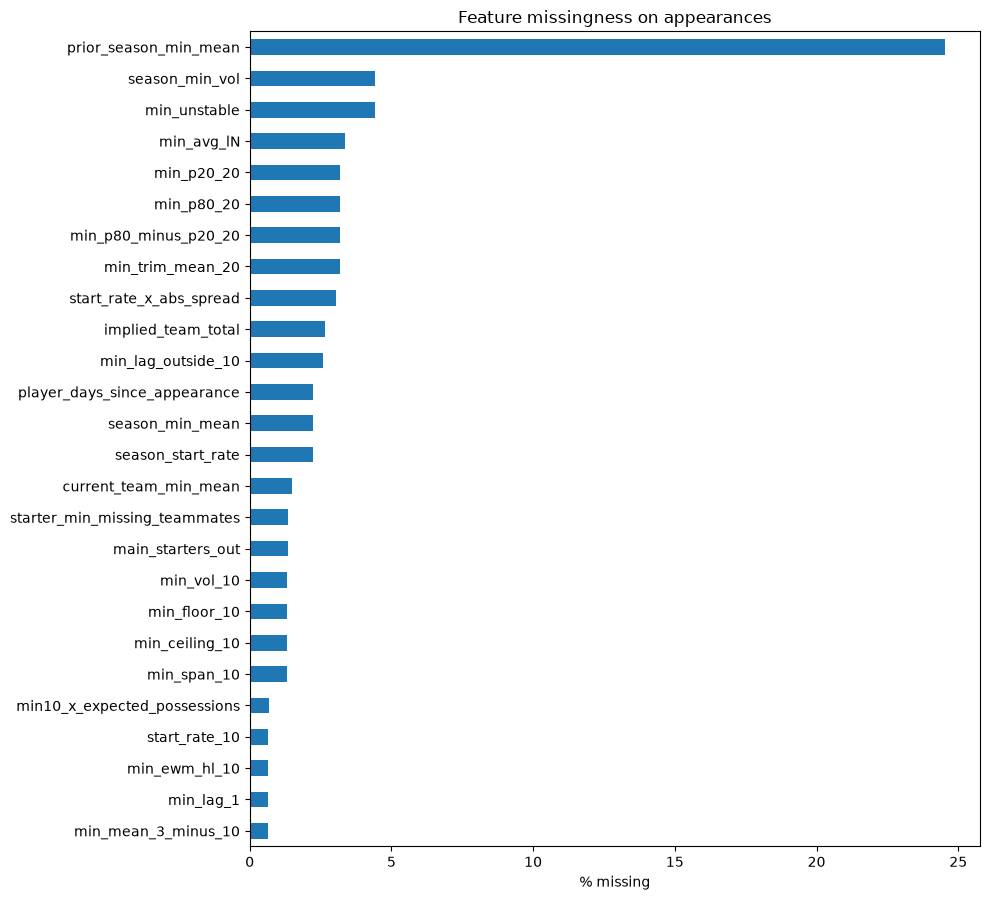

In [16]:
# Feature missingness

miss = pd.DataFrame({
    "n_missing": df[MIN_FEATURES].isna().sum(),
    "pct_missing": (df[MIN_FEATURES].isna().mean() * 100).round(2),
}).sort_values(["pct_missing", "n_missing"], ascending=False)

n_any = int(df[MIN_FEATURES].isna().any(axis=1).sum())
print(f"Appearance rows: {len(df):,}")
print(f"Features with a null: {int((miss['n_missing'] > 0).sum())} / {len(MIN_FEATURES)}")
print(f"Rows with any null feature: {n_any:,} ({n_any / len(df):.1%})")

sparse = miss.index[miss["n_missing"] > 0].tolist()
display(miss)
if sparse:
    season_miss_pct = (
        df[sparse]
        .isna()
        .groupby(df["season_year"], sort=True)
        .mean()
        .mul(100)
        .round(1)
    )
    display(season_miss_pct)
    fig, ax = plt.subplots(figsize=(10, max(3, 0.35 * len(sparse))))
    miss.loc[sparse, "pct_missing"].sort_values().plot.barh(ax=ax, color="C0")
    ax.set_xlabel("% missing")
    ax.set_title("Feature missingness on appearances")
    fig.tight_layout()
    plt.show()
else:
    print("Every selected feature is complete on this frame.")


n=176,710  min=0.02  p50=23.65  max=56.52
Tukey fence [-9.27, 55.59]  outside=4 (0.0%)
Player minutes above 48 (overtime range): 81


,season_year,game_date,player_name,minutes,starting
62209,2021-22,2022-01-29,Pascal Siakam,56.516667,1
141903,2021-22,2022-01-29,Scottie Barnes,56.333333,1
71545,2021-22,2022-01-29,OG Anunoby,55.816667,1
92124,2021-22,2022-01-29,Gary Trent Jr.,55.650000,1
126602,2022-23,2023-03-05,Immanuel Quickley,55.100000,1
123639,2023-24,2024-04-07,Tyrese Maxey,53.950000,1
64751,2021-22,2022-01-29,Fred VanVleet,53.516667,1
155436,2024-25,2025-04-01,Christian Braun,53.166667,1


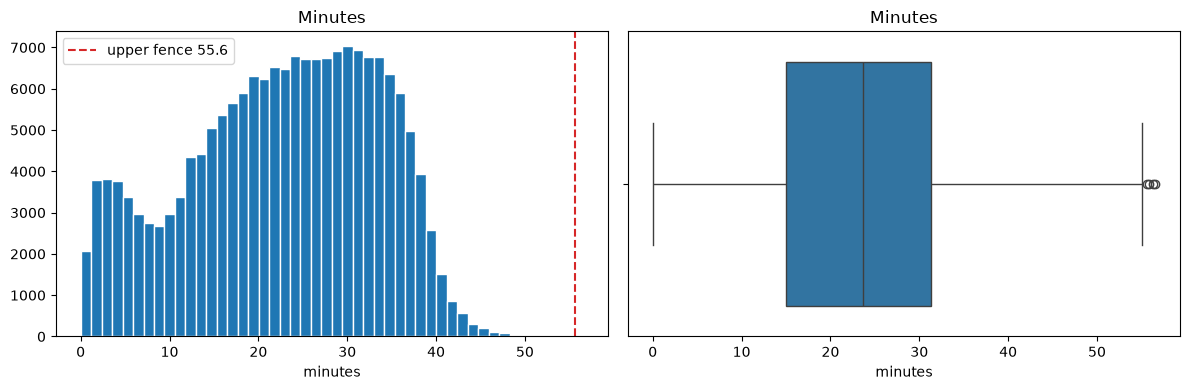

Binary inputs are omitted. A point is outside when it is past 1.5 IQR from the quartiles.


,feature,n,pct_outside,fence_low,fence_high,min,p50,max
0,player_days_since_appearance,172774,10.05,0.50,4.50,1.00,2.00,30.00
1,player_appearances_prev_7d,176710,7.79,0.50,4.50,0.00,3.00,5.00
2,min_vol_10,174390,5.20,-0.24,0.82,0.00,0.24,2.23
3,start_rate_x_abs_spread,171359,4.54,-6.75,11.25,0.00,1.30,25.50
4,min_mean_3_minus_10,175538,3.51,-8.24,8.30,-22.92,0.00,24.58
5,season_min_vol,168896,3.32,-0.26,0.87,0.00,0.26,1.99
6,min_p80_minus_p20_20,171081,2.84,-0.79,18.87,0.32,8.74,34.36
7,main_starters_out,174350,2.12,-1.50,2.50,0.00,0.00,5.00
8,starter_min_missing_teammates,174350,2.01,-47.19,78.66,0.00,0.00,177.64
9,min_ceiling_10,174390,1.57,8.60,55.53,0.43,33.00,56.52


In [17]:
# Outliers

minutes = df["minutes"]
q1, q3 = minutes.quantile(0.25), minutes.quantile(0.75)
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
n_tukey = int(((minutes < lo) | (minutes > hi)).sum())
n_ot = int((minutes > 48).sum())
print(
    f"n={len(minutes):,}  min={minutes.min():.2f}  "
    f"p50={minutes.median():.2f}  max={minutes.max():.2f}"
)
print(
    f"Tukey fence [{lo:.2f}, {hi:.2f}]  "
    f"outside={n_tukey:,} ({n_tukey / len(minutes):.1%})"
)
print(f"Player minutes above 48 (overtime range): {n_ot:,}")

top_minutes = (
    df.nlargest(8, "minutes")[
        ["season_year", "game_date", "player_name", "minutes", "starting"]
    ]
    .assign(game_date=lambda frame: pd.to_datetime(frame["game_date"]).dt.date)
)
display(top_minutes)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(minutes, bins=48, color="C0", edgecolor="white")
axes[0].axvline(hi, color="C3", ls="--", label=f"upper fence {hi:.1f}")
axes[0].set_title("Minutes")
axes[0].set_xlabel("minutes")
axes[0].legend()
sns.boxplot(x=minutes, ax=axes[1], color="C0")
axes[1].set_title("Minutes")
fig.tight_layout()
plt.show()

outlier_rows = []
for col in MIN_FEATURES:
    values = df[col].dropna()
    if values.nunique(dropna=True) <= 2:
        continue
    fq1, fq3 = values.quantile([0.25, 0.75])
    spread = float(fq3 - fq1)
    if spread <= 0:
        continue
    fence_lo = float(fq1 - 1.5 * spread)
    fence_hi = float(fq3 + 1.5 * spread)
    outside = (values < fence_lo) | (values > fence_hi)
    outlier_rows.append({
        "feature": col,
        "n": int(values.shape[0]),
        "pct_outside": round(100 * float(outside.mean()), 2),
        "fence_low": round(fence_lo, 2),
        "fence_high": round(fence_hi, 2),
        "min": round(float(values.min()), 2),
        "p50": round(float(values.median()), 2),
        "max": round(float(values.max()), 2),
    })

feature_outliers = (
    pd.DataFrame(outlier_rows)
    .sort_values("pct_outside", ascending=False)
    .reset_index(drop=True)
)
print("Binary inputs are omitted. A point is outside when it is past 1.5 IQR from the quartiles.")
display(feature_outliers)


In [18]:
# Coverage by Season

complete = ~df[MIN_FEATURES].isna().any(axis=1)
coverage = df.groupby("season_year", sort=True).agg(
    rows=("player_id", "size"),
    players=("player_id", "nunique"),
    games=("game_id", "nunique"),
    first_game=("game_date", "min"),
    last_game=("game_date", "max"),
)
coverage["first_game"] = pd.to_datetime(coverage["first_game"]).dt.date
coverage["last_game"] = pd.to_datetime(coverage["last_game"]).dt.date
coverage["pct_rows_complete"] = (
    complete.groupby(df["season_year"], sort=True).mean().mul(100).round(1)
)
coverage["mean_missing_features"] = (
    df[MIN_FEATURES]
    .isna()
    .sum(axis=1)
    .groupby(df["season_year"], sort=True)
    .mean()
    .round(2)
)
print(f"Seasons: {len(coverage)}  rows: {int(coverage['rows'].sum()):,}")
display(coverage)

Seasons: 7  rows: 176,710


,rows,players,games,first_game,last_game,pct_rows_complete,mean_missing_features
season_year,,,,,,,
2019-20,22387,529,1059,2019-10-22,2020-08-14,0.0,2.29
2020-21,23053,540,1080,2020-12-22,2021-05-16,81.4,0.55
2021-22,26035,605,1230,2021-10-19,2022-04-10,78.3,0.63
2022-23,25892,539,1230,2022-10-18,2023-04-09,82.7,0.48
2023-24,26393,572,1230,2023-10-24,2024-04-14,79.6,0.57
2024-25,26302,569,1230,2024-10-22,2025-04-13,81.4,0.52
2025-26,26648,582,1230,2025-10-21,2026-04-12,79.7,0.56


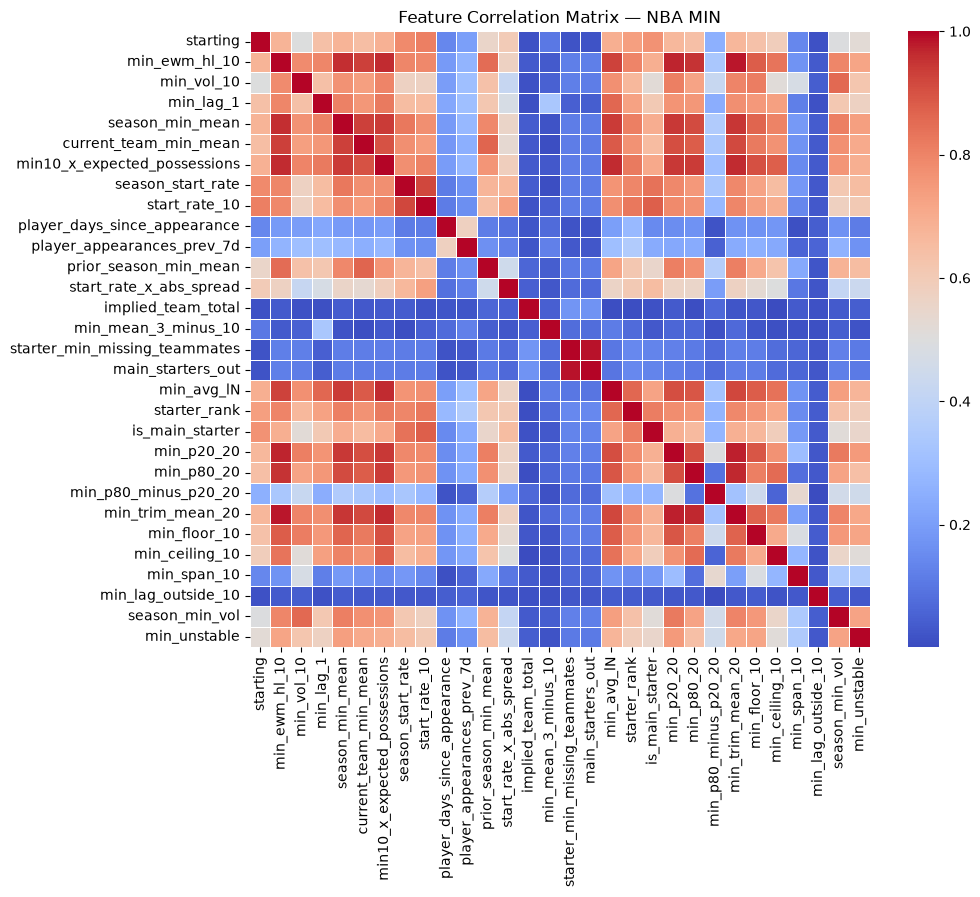

--- High Correlation Report (Threshold > 0.95) ---
main_starters_out <-> starter_min_missing_teammates: 0.9865
min_trim_mean_20 <-> min_ewm_hl_10: 0.9836
min_trim_mean_20 <-> min_p20_20: 0.9760
min_p20_20 <-> min_ewm_hl_10: 0.9702
min_trim_mean_20 <-> min_p80_20: 0.9676
min10_x_expected_possessions <-> min_ewm_hl_10: 0.9646
min_trim_mean_20 <-> min10_x_expected_possessions: 0.9636
min_avg_lN <-> min10_x_expected_possessions: 0.9624
season_min_mean <-> min_ewm_hl_10: 0.9574
min_p80_20 <-> min_ewm_hl_10: 0.9520


['season_min_mean',
 'min10_x_expected_possessions',
 'main_starters_out',
 'min_avg_lN',
 'min_p20_20',
 'min_p80_20',
 'min_trim_mean_20']

In [19]:
correlated_features = analyze_correlations(
    df, MIN_FEATURES, title="Feature Correlation Matrix — NBA MIN"
)
correlated_features

### Models

In [28]:
# Hyperparameter tuning
# Leave commented if you don't want to retune the model

# import importlib
# import models.shared.train as train

# importlib.reload(train)
# tune_xgb_quantile = train.tune_xgb_quantile

# result = tune_xgb_quantile(X, y, n_trials=50, n_splits=3)
# XGB_PARAMS = result["best_params"]

# lgb_result = tune_lgb_quantile(
#     ppm_df[MIN_FEATURES],
#     ppm_df[TARGET_COL],
#     n_trials=40,
#     n_splits=4,
#     seed=SEED,
# )
# LGB_PARAMS = lgb_result["best_params"]


In [20]:
# Model 1: XGBoost using time series cross validation and walk forward validation

tscv_results = run_timeseries_cv(
    X, y, ppm_df,
    xgb_params=XGB_PARAMS,
    role_col=ROLE_COL,
    tiers=MIN_TIERS,
    quantiles=QUANTILES,
)
wf = run_walk_forward(
    X, y, ppm_df,
    xgb_params=XGB_PARAMS,
    role_col=ROLE_COL,
    tiers=MIN_TIERS,
    quantiles=QUANTILES,
)

wf_results = wf["wf_results"]
models_last = wf["models_last"]
preds_last = wf["preds_last"]
X_val_last = wf["X_val_last"]
y_val_last = wf["y_val_last"]
starting_last = wf["starting_last"]
last_fold = wf["last_fold"]


── Phase 1: TimeSeriesSplit (XGBoost) ──────────────────────────

TSCV fold 1
  n=25010
  pinball  | q0.05=0.601  q0.10=0.998  q0.20=1.578  q0.30=1.946  q0.40=2.157  q0.50=2.219  q0.60=2.143  q0.70=1.931  q0.80=1.557  q0.90=0.985  q0.95=0.590
  coverage | 80%=78.3% (target 80%)  90%=89.1% (target 90%)
  Starters   | n=11707 | pinball q50: 2.103 | 80% coverage: 78.5%
  Bench      | n=13303 | pinball q50: 2.321 | 80% coverage: 78.2%
  minute tiers by predicted q50
  <15 min    | n= 5771 | pinball q50: 2.354 | 80% coverage: 78.3%
  15-24 min  | n= 7285 | pinball q50: 2.379 | 80% coverage: 78.1%
  24-31 min  | n= 6033 | pinball q50: 2.230 | 80% coverage: 78.7%
  31+ min    | n= 5921 | pinball q50: 1.879 | 80% coverage: 78.4%

TSCV fold 2
  n=25010
  pinball  | q0.05=0.628  q0.10=1.043  q0.20=1.635  q0.30=2.012  q0.40=2.225  q0.50=2.295  q0.60=2.215  q0.70=1.993  q0.80=1.606  q0.90=1.014  q0.95=0.603
  coverage | 80%=78.2% (target 80%)  90%=88.7% (target 90%)
  Starters   | n=11824 | pinbal

In [ ]:
# Model 2: LightGBM using the same TimeSeriesSplit and walk-forward path

import importlib
import models.shared.train as train_mod

importlib.reload(train_mod)
run_timeseries_cv = train_mod.run_timeseries_cv
run_walk_forward = train_mod.run_walk_forward

tscv_results_lgb = run_timeseries_cv(
    X, y, ppm_df,
    lgb_params=LGB_PARAMS,
    role_col=ROLE_COL,
    tiers=MIN_TIERS,
    quantiles=QUANTILES,
)
wf_lgb = run_walk_forward(
    X, y, ppm_df,
    lgb_params=LGB_PARAMS,
    role_col=ROLE_COL,
    tiers=MIN_TIERS,
    quantiles=QUANTILES,
)

wf_results_lgb = wf_lgb["wf_results"]
models_last_lgb = wf_lgb["models_last"]
preds_last_lgb = wf_lgb["preds_last"]

── Phase 1: TimeSeriesSplit (LightGBM) ──────────────────────────


/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is


TSCV fold 1
  n=25010
  pinball  | q0.05=0.605  q0.10=1.005  q0.20=1.578  q0.30=1.944  q0.40=2.147  q0.50=2.208  q0.60=2.133  q0.70=1.925  q0.80=1.560  q0.90=0.994  q0.95=0.600
  coverage | 80%=76.3% (target 80%)  90%=87.3% (target 90%)
  Starters   | n=11707 | pinball q50: 2.096 | 80% coverage: 76.8%
  Bench      | n=13303 | pinball q50: 2.306 | 80% coverage: 75.8%
  minute tiers by predicted q50
  <15 min    | n= 5599 | pinball q50: 2.322 | 80% coverage: 74.4%
  15-24 min  | n= 7349 | pinball q50: 2.376 | 80% coverage: 76.5%
  24-31 min  | n= 6124 | pinball q50: 2.228 | 80% coverage: 77.3%
  31+ min    | n= 5938 | pinball q50: 1.872 | 80% coverage: 76.8%


/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is


TSCV fold 2
  n=25010
  pinball  | q0.05=0.630  q0.10=1.045  q0.20=1.634  q0.30=2.009  q0.40=2.224  q0.50=2.292  q0.60=2.214  q0.70=1.990  q0.80=1.606  q0.90=1.014  q0.95=0.607
  coverage | 80%=77.2% (target 80%)  90%=87.6% (target 90%)
  Starters   | n=11824 | pinball q50: 2.158 | 80% coverage: 77.0%
  Bench      | n=13186 | pinball q50: 2.411 | 80% coverage: 77.3%
  minute tiers by predicted q50
  <15 min    | n= 5410 | pinball q50: 2.430 | 80% coverage: 76.0%
  15-24 min  | n= 7351 | pinball q50: 2.437 | 80% coverage: 78.4%
  24-31 min  | n= 6019 | pinball q50: 2.378 | 80% coverage: 76.5%
  31+ min    | n= 6230 | pinball q50: 1.916 | 80% coverage: 77.3%


...

/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is


TSCV fold 5
  n=25010
  pinball  | q0.05=0.607  q0.10=1.004  q0.20=1.568  q0.30=1.929  q0.40=2.133  q0.50=2.196  q0.60=2.126  q0.70=1.913  q0.80=1.544  q0.90=0.981  q0.95=0.587
  coverage | 80%=79.0% (target 80%)  90%=89.0% (target 90%)
  Starters   | n=11719 | pinball q50: 2.069 | 80% coverage: 79.4%
  Bench      | n=13291 | pinball q50: 2.307 | 80% coverage: 78.5%
  minute tiers by predicted q50
  <15 min    | n= 5990 | pinball q50: 2.343 | 80% coverage: 77.7%
  15-24 min  | n= 6710 | pinball q50: 2.339 | 80% coverage: 79.3%
  24-31 min  | n= 6076 | pinball q50: 2.204 | 80% coverage: 79.9%
  31+ min    | n= 6234 | pinball q50: 1.892 | 80% coverage: 78.9%

TimeSeriesSplit Summary (LightGBM)
  Pinball q50 : 2.232 ± 0.033
  Coverage 80%: 77.6% ± 0.9%  (target 80%)

── Phase 2: Walk-Forward Validation (LightGBM, date-based) ──────
Unique game dates in pool : 942
Training window           : 471 dates (~50%)
Step size                 : 94 dates (~10%)


/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is


WF fold 1  (2022-11-02 → 2023-02-07)
  n=14737
  pinball  | q0.05=0.623  q0.10=1.029  q0.20=1.599  q0.30=1.963  q0.40=2.163  q0.50=2.221  q0.60=2.144  q0.70=1.931  q0.80=1.562  q0.90=0.989  q0.95=0.589
  coverage | 80%=78.2% (target 80%)  90%=88.0% (target 90%)
  Starters   | n= 7030 | pinball q50: 2.066 | 80% coverage: 78.1%
  Bench      | n= 7707 | pinball q50: 2.362 | 80% coverage: 78.4%
  minute tiers by predicted q50
  <15 min    | n= 3320 | pinball q50: 2.394 | 80% coverage: 78.5%
  15-24 min  | n= 4016 | pinball q50: 2.376 | 80% coverage: 78.7%
  24-31 min  | n= 3340 | pinball q50: 2.253 | 80% coverage: 78.3%
  31+ min    | n= 4061 | pinball q50: 1.899 | 80% coverage: 77.6%


/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is

In [22]:
def score_predictions(y_true, preds, split: str):
    """Pinball loss per quantile and central interval coverage."""
    y_true = np.asarray(y_true, dtype=float)
    pinball_rows = []
    for key, pred in preds.items():
        alpha = float(str(key).split("_", 1)[1])
        pinball_rows.append({
            "split": split,
            "quantile": alpha,
            "pinball": pinball_loss(y_true, pred, alpha),
        })
    coverage_rows = []
    for low, high, nominal in ((0.10, 0.90, 0.80), (0.05, 0.95, 0.90)):
        low_key, high_key = f"q_{low:.2f}", f"q_{high:.2f}"
        if low_key not in preds or high_key not in preds:
            continue
        coverage_rows.append({
            "split": split,
            "interval": f"{nominal:.0%}",
            "coverage": interval_coverage(y_true, preds[low_key], preds[high_key]),
            "target": nominal,
        })
    return pd.DataFrame(pinball_rows), pd.DataFrame(coverage_rows)


wf_pinball, wf_coverage = score_predictions(
    y_val_last, preds_last, last_fold["fold"]
)
display(wf_pinball.round(4))
display(wf_coverage.round(4))

,split,quantile,pinball
0,WF fold 4 (2024-03-17 → 2025-01-02),0.05,0.6070
1,WF fold 4 (2024-03-17 → 2025-01-02),0.10,1.0084
2,WF fold 4 (2024-03-17 → 2025-01-02),0.20,1.5833
3,WF fold 4 (2024-03-17 → 2025-01-02),0.30,1.9532
4,WF fold 4 (2024-03-17 → 2025-01-02),0.40,2.1647
5,WF fold 4 (2024-03-17 → 2025-01-02),0.50,2.2269
6,WF fold 4 (2024-03-17 → 2025-01-02),0.60,2.1621
7,WF fold 4 (2024-03-17 → 2025-01-02),0.70,1.9458
8,WF fold 4 (2024-03-17 → 2025-01-02),0.80,1.5703
9,WF fold 4 (2024-03-17 → 2025-01-02),0.90,0.9913


,split,interval,coverage,target
0,WF fold 4 (2024-03-17 → 2025-01-02),80%,0.7872,0.8
1,WF fold 4 (2024-03-17 → 2025-01-02),90%,0.8918,0.9


In [23]:
# Test xgboost model on holdout set

holdout = evaluate_holdout(
    ppm_df,
    ppm_holdout,
    features=MIN_FEATURES,
    target_col=TARGET_COL,
    xgb_params=XGB_PARAMS,
    role_col=ROLE_COL,
    tiers=MIN_TIERS,
    wf_results=wf_results,
    quantiles=QUANTILES,
    fold_label=f"{HOLDOUT_SEASON} Blind Holdout",
)
models_ho = holdout["models_ho"]
preds_ho = holdout["preds_ho"]
ho_metrics = holdout["ho_metrics"]
X_ho = holdout["X_ho"]
y_ho = holdout["y_ho"]

ho_pinball, ho_coverage = score_predictions(
    y_ho, preds_ho, f"{HOLDOUT_SEASON} holdout"
)
display(ho_pinball.round(4))
display(ho_coverage.round(4))

── 2025-26 Blind Holdout ─────────────────────────────────────────────────
  Train pool: 90% rows for fit, remainder for early-stopping only; predict holdout (never in eval_set).

2025-26 Blind Holdout
  n=26648
  pinball  | q0.05=0.610  q0.10=1.009  q0.20=1.579  q0.30=1.943  q0.40=2.148  q0.50=2.216  q0.60=2.146  q0.70=1.935  q0.80=1.565  q0.90=0.993  q0.95=0.589
  coverage | 80%=79.6% (target 80%)  90%=89.5% (target 90%)
  Starters   | n=12300 | pinball q50: 2.066 | 80% coverage: 80.6%
  Bench      | n=14348 | pinball q50: 2.345 | 80% coverage: 78.7%
  minute tiers by predicted q50
  <15 min    | n= 6280 | pinball q50: 2.444 | 80% coverage: 78.0%
  15-24 min  | n= 7614 | pinball q50: 2.316 | 80% coverage: 79.2%
  24-31 min  | n= 7110 | pinball q50: 2.157 | 80% coverage: 80.4%
  31+ min    | n= 5644 | pinball q50: 1.902 | 80% coverage: 80.6%

───────────────────────────────────────────────────────
  Walk-forward pinball q50 (mean) : 2.225
  Holdout pinball q50             : 2.216
  Pi

,split,quantile,pinball
0,2025-26 holdout,0.05,0.6097
1,2025-26 holdout,0.10,1.0093
2,2025-26 holdout,0.20,1.5792
3,2025-26 holdout,0.30,1.9430
4,2025-26 holdout,0.40,2.1480
5,2025-26 holdout,0.50,2.2162
6,2025-26 holdout,0.60,2.1461
7,2025-26 holdout,0.70,1.9351
8,2025-26 holdout,0.80,1.5654
9,2025-26 holdout,0.90,0.9932


,split,interval,coverage,target
0,2025-26 holdout,80%,0.7957,0.8
1,2025-26 holdout,90%,0.8947,0.9


In [24]:
# Test lightgbm model on holdout set

holdout_lgb = evaluate_holdout(
    ppm_df,
    ppm_holdout,
    features=MIN_FEATURES,
    target_col=TARGET_COL,
    lgb_params=LGB_PARAMS,
    role_col=ROLE_COL,
    tiers=MIN_TIERS,
    wf_results=wf_results_lgb,
    quantiles=QUANTILES,
    fold_label=f"{HOLDOUT_SEASON} LightGBM Blind Holdout",
)
models_lgb = holdout_lgb["models_ho"]
preds_lgb = holdout_lgb["preds_ho"]
ho_metrics_lgb = holdout_lgb["ho_metrics"]
X_lgb_ho = holdout_lgb["X_ho"]
y_lgb_ho = holdout_lgb["y_ho"]

lgb_pinball, lgb_coverage = score_predictions(
    y_lgb_ho, preds_lgb, f"{HOLDOUT_SEASON} lightgbm holdout"
)
display(lgb_pinball.round(4))
display(lgb_coverage.round(4))


NameError: name 'wf_results_lgb' is not defined

In [ ]:
# empirical quantile calibration
y_true = np.asarray(y_ho, dtype=float)
calibration_rows = []
for key, pred in preds_ho.items():
    alpha = float(str(key).split("_", 1)[1])
    pred = np.asarray(pred, dtype=float)
    empirical = float(np.mean(y_true <= pred))
    calibration_rows.append({
        "quantile": alpha,
        "target": alpha,
        "empirical": empirical,
        "delta": empirical - alpha,
    })
calibration = (
    pd.DataFrame(calibration_rows)
    .sort_values("quantile")
    .reset_index(drop=True)
)

print(f"{HOLDOUT_SEASON} holdout — empirical quantile calibration")
display(calibration.round(4))


2025-26 holdout — empirical quantile calibration


,quantile,target,empirical,delta
0,0.05,0.05,0.0504,0.0004
1,0.10,0.10,0.0988,-0.0012
2,0.20,0.20,0.1955,-0.0045
3,0.30,0.30,0.2932,-0.0068
4,0.40,0.40,0.3961,-0.0039
5,0.50,0.50,0.4988,-0.0012
6,0.60,0.60,0.6007,0.0007
7,0.70,0.70,0.6996,-0.0004
8,0.80,0.80,0.8005,0.0005
9,0.90,0.90,0.8971,-0.0029


In [17]:
quantile_keys = sorted(
    preds_ho,
    key=lambda key: float(str(key).split("_", 1)[1]),
)
grid = np.column_stack([
    np.asarray(preds_ho[key], dtype=float) for key in quantile_keys
])
crossed = np.any(np.diff(grid, axis=1) < 0, axis=1)
n_rows = int(len(crossed))
n_crossed = int(crossed.sum())
print(
    f"{HOLDOUT_SEASON} holdout quantile crossing: "
    f"{n_crossed:,} / {n_rows:,} rows ({n_crossed / n_rows:.1%})"
)

pair_rows = []
for left, right in zip(quantile_keys, quantile_keys[1:]):
    pair_rate = float(np.mean(
        np.asarray(preds_ho[left], dtype=float)
        > np.asarray(preds_ho[right], dtype=float)
    ))
    pair_rows.append({
        "lower": left,
        "upper": right,
        "crossing_rate": pair_rate,
    })
crossing_pairs = pd.DataFrame(pair_rows)
display(crossing_pairs.round(4))


2025-26 holdout quantile crossing: 491 / 26,648 rows (1.8%)


,lower,upper,crossing_rate
0,q_0.05,q_0.10,0.0009
1,q_0.10,q_0.20,0.0012
2,q_0.20,q_0.30,0.0031
3,q_0.30,q_0.40,0.0039
4,q_0.40,q_0.50,0.0041
5,q_0.50,q_0.60,0.0026
6,q_0.60,q_0.70,0.0024
7,q_0.70,q_0.80,0.0011
8,q_0.80,q_0.90,0.0002
9,q_0.90,q_0.95,0.0005


In [18]:
predicted = np.asarray(preds_ho["q_0.50"], dtype=float)
y_true = np.asarray(y_ho, dtype=float)
low_80 = np.asarray(preds_ho["q_0.10"], dtype=float)
high_80 = np.asarray(preds_ho["q_0.90"], dtype=float)
low_90 = np.asarray(preds_ho["q_0.05"], dtype=float)
high_90 = np.asarray(preds_ho["q_0.95"], dtype=float)
width_80 = high_80 - low_80
width_90 = high_90 - low_90

tier_rows = []
for name, fn in MIN_TIERS.items():
    mask = np.asarray(fn(predicted), dtype=bool)
    n = int(mask.sum())
    if n == 0:
        continue
    tier_rows.append({
        "tier": name,
        "n": n,
        "share": n / len(predicted),
        "pinball_q50": pinball_loss(y_true[mask], predicted[mask], 0.50),
        "empirical_q50": float(np.mean(y_true[mask] <= predicted[mask])),
        "coverage_80": interval_coverage(y_true[mask], low_80[mask], high_80[mask]),
        "coverage_90": interval_coverage(y_true[mask], low_90[mask], high_90[mask]),
        "mean_width_80": float(np.mean(width_80[mask])),
        "mean_width_90": float(np.mean(width_90[mask])),
    })
tier_report = pd.DataFrame(tier_rows)
print(f"{HOLDOUT_SEASON} holdout — minute tiers by predicted q50")
display(tier_report.round(4))


2025-26 holdout — minute tiers by predicted q50


,tier,n,share,pinball_q50,empirical_q50,coverage_80,coverage_90,mean_width_80,mean_width_90
0,<15 min,6290,0.2360,2.4456,0.4893,0.7806,0.8860,14.9092,18.8791
1,15-24 min,7602,0.2853,2.3187,0.4825,0.7939,0.8933,14.9222,19.5371
2,24-31 min,7144,0.2681,2.1469,0.5088,0.8110,0.9041,13.8918,17.9525
3,31+ min,5612,0.2106,1.9150,0.5189,0.8076,0.9011,11.9933,15.8080


In [21]:
# Holdout RMSE, CRPS, and tail calibration.
# CRPS is twice the mean pinball across the trained knots.
# Lower tail: share of outcomes at or below the knot.
# Upper tail: share of outcomes above the knot.

from models.shared.minutes_sampler import row_crps

TAIL_KNOTS = (
    ("lower", 0.05),
    ("lower", 0.10),
    ("upper", 0.90),
    ("upper", 0.95),
)


def holdout_point_distribution(name, y, preds):
    y = np.asarray(y, dtype=float)
    levels = sorted(float(str(key).split("_", 1)[1]) for key in preds)
    grid = np.column_stack(
        [np.asarray(preds[f"q_{level:.2f}"], dtype=float) for level in levels]
    )
    q50 = np.asarray(preds["q_0.50"], dtype=float)
    return {
        "model": name,
        "rmse": float(np.sqrt(mean_squared_error(y, q50))),
        "crps": float(np.mean(row_crps(y, grid, np.asarray(levels)))),
    }


def tail_calibration_rows(name, y, preds):
    y = np.asarray(y, dtype=float)
    rows = []
    for side, level in TAIL_KNOTS:
        knot = np.asarray(preds[f"q_{level:.2f}"], dtype=float)
        if side == "lower":
            nominal = level
            empirical = float(np.mean(y <= knot))
        else:
            nominal = 1.0 - level
            empirical = float(np.mean(y > knot))
        rows.append({
            "model": name,
            "side": side,
            "quantile": level,
            "nominal": nominal,
            "empirical": empirical,
            "delta": empirical - nominal,
        })
    return rows


holdout_models = (
    ("XGBoost", y_ho, preds_ho),
    ("LightGBM", y_lgb_ho, preds_lgb),
)
score_table = pd.DataFrame(
    [holdout_point_distribution(name, y, preds) for name, y, preds in holdout_models]
)
tail_calibration = pd.DataFrame(
    [
        row
        for name, y, preds in holdout_models
        for row in tail_calibration_rows(name, y, preds)
    ]
)

print(
    f"{HOLDOUT_SEASON} holdout — q50 RMSE and 11-knot CRPS\n"
    "  CRPS is twice the mean pinball across the trained knots"
)
display(score_table.round(4))
print(
    f"{HOLDOUT_SEASON} holdout — tail calibration\n"
    "  delta is empirical minus nominal. "
    "A positive delta means more outcomes landed in that tail than the quantile claims"
)
display(tail_calibration.round(4))


2025-26 holdout — q50 RMSE and 11-knot CRPS
  CRPS is twice the mean pinball across the trained knots


,model,rmse,crps
0,XGBoost,5.8419,3.0447
1,LightGBM,5.8336,3.0419


2025-26 holdout — tail calibration
  delta is empirical minus nominal. A positive delta means more outcomes landed in that tail than the quantile claims


,model,side,quantile,nominal,empirical,delta
0,XGBoost,lower,0.05,0.05,0.0504,0.0004
1,XGBoost,lower,0.10,0.10,0.0988,-0.0012
2,XGBoost,upper,0.90,0.10,0.1029,0.0029
3,XGBoost,upper,0.95,0.05,0.0535,0.0035
4,LightGBM,lower,0.05,0.05,0.0532,0.0032
5,LightGBM,lower,0.10,0.10,0.1024,0.0024
6,LightGBM,upper,0.90,0.10,0.1049,0.0049
7,LightGBM,upper,0.95,0.05,0.0550,0.0050


In [22]:
def interval_sharpness(y_true, preds):
    y_true = np.asarray(y_true, dtype=float)
    rows = []
    for low, high, nominal in ((0.10, 0.90, 0.80), (0.05, 0.95, 0.90)):
        low_key, high_key = f"q_{low:.2f}", f"q_{high:.2f}"
        width = (
            np.asarray(preds[high_key], dtype=float)
            - np.asarray(preds[low_key], dtype=float)
        )
        rows.append({
            "interval": f"{nominal:.0%}",
            "coverage": interval_coverage(y_true, preds[low_key], preds[high_key]),
            "target": nominal,
            "mean_width": float(np.mean(width)),
            "median_width": float(np.median(width)),
        })
    return pd.DataFrame(rows)

sharp_xgb = interval_sharpness(y_ho, preds_ho)
sharp_lgb = interval_sharpness(y_lgb_ho, preds_lgb)

cmp_sharpness = (
    sharp_xgb[["interval", "target", "coverage", "mean_width", "median_width"]]
    .merge(
        sharp_lgb[["interval", "coverage", "mean_width", "median_width"]],
        on="interval",
        suffixes=("_xgb", "_lgb"),
    )
)
cmp_sharpness["mean_width_xgb_minus_lgb"] = (
    cmp_sharpness["mean_width_xgb"] - cmp_sharpness["mean_width_lgb"]
)

print(
    f"{HOLDOUT_SEASON} holdout — interval sharpness (minutes)\n"
    "  mean_width_xgb_minus_lgb < 0 means the XGBoost interval is narrower"
)
display(cmp_sharpness.round(4))


2025-26 holdout — interval sharpness (minutes)
  mean_width_xgb_minus_lgb < 0 means the XGBoost interval is narrower


,interval,target,coverage_xgb,mean_width_xgb,median_width_xgb,coverage_lgb,mean_width_lgb,median_width_lgb,mean_width_xgb_minus_lgb
0,80%,0.8,0.7982,14.0261,13.7425,0.7927,13.8862,13.6336,0.1399
1,90%,0.9,0.8961,18.1716,17.9024,0.8918,18.0404,17.7949,0.1313


### Baseline

In [24]:
N_BOOT = 2_000
SEED = 42
WIS_INTERVALS = (
    (0.80, "q_0.40", "q_0.60"),
    (0.60, "q_0.30", "q_0.70"),
    (0.40, "q_0.20", "q_0.80"),
    (0.20, "q_0.10", "q_0.90"),
    (0.10, "q_0.05", "q_0.95"),
)

XGB_NAME = "Quantile XGBoost"
LGB_NAME = "Quantile LightGBM"

y_all = np.asarray(y_ho, dtype=float)
model_quantiles = {
    XGB_NAME: {key: np.asarray(pred, dtype=float) for key, pred in preds_ho.items()},
    LGB_NAME: {key: np.asarray(pred, dtype=float) for key, pred in preds_lgb.items()},
}
for name, qmap in model_quantiles.items():
    if len(next(iter(qmap.values()))) != len(y_all):
        raise ValueError(f"{name} predictions do not match the holdout length")
alpha_of = {
    key: float(str(key).split("_", 1)[1]) for key in model_quantiles[XGB_NAME]
}
ordered_keys = sorted(model_quantiles[XGB_NAME], key=alpha_of.get)
baselines = {
    "Last-game minutes": ppm_holdout["min_lag_1"].to_numpy(dtype=float),
    "Season-to-date average": ppm_holdout["season_min_mean"].to_numpy(dtype=float),
    "EWMA minutes": ppm_holdout["min_ewm_hl_10"].to_numpy(dtype=float),
}
paired = np.isfinite(y_all)
for qmap in model_quantiles.values():
    paired &= np.isfinite(qmap["q_0.50"])
for pred in baselines.values():
    paired &= np.isfinite(pred)

def point_row(name, y, pred):
    error = y - pred
    absolute = np.abs(error)
    return {
        "model": name,
        "mae": float(absolute.mean()),
        "median_ae": float(np.median(absolute)),
        "mean_bias": float(error.mean()),
    }

def interval_score(y, lower, upper, alpha):
    width = upper - lower
    below = y < lower
    above = y > upper
    return (
        width
        + (2.0 / alpha) * (lower - y) * below
        + (2.0 / alpha) * (y - upper) * above
    )

def wis_values(y, qmap):
    present = [
        (alpha, qmap[low], qmap[high])
        for alpha, low, high in WIS_INTERVALS
        if low in qmap and high in qmap
    ]
    total = 0.5 * np.abs(y - qmap["q_0.50"])
    for alpha, lower, upper in present:
        total = total + (alpha / 2.0) * interval_score(y, lower, upper, alpha)
    return total / (len(present) + 0.5)

def clustered_mae_bootstrap(y, predictors, dates, n_boot, seed):
    codes, _ = pd.factorize(dates, sort=False)
    n_clusters = int(codes.max()) + 1
    cluster_n = np.bincount(codes).astype(float)
    cluster_sum = {
        name: np.bincount(codes, weights=np.abs(y - pred))
        for name, pred in predictors.items()
    }
    rng = np.random.default_rng(seed)
    draws = rng.integers(0, n_clusters, size=(n_boot, n_clusters))
    weights = np.zeros((n_boot, n_clusters), dtype=np.int32)
    np.add.at(
        weights,
        (np.repeat(np.arange(n_boot), n_clusters), draws.ravel()),
        1,
    )
    denom = weights @ cluster_n
    return {name: (weights @ total) / denom for name, total in cluster_sum.items()}

y_paired = y_all[paired]
xgb_q50_name = f"{XGB_NAME} q50"
lgb_q50_name = f"{LGB_NAME} q50"
paired_preds = {
    xgb_q50_name: model_quantiles[XGB_NAME]["q_0.50"][paired],
    lgb_q50_name: model_quantiles[LGB_NAME]["q_0.50"][paired],
}
paired_preds.update({name: pred[paired] for name, pred in baselines.items()})
dates_paired = pd.to_datetime(ppm_holdout["game_date"]).to_numpy()[paired]
boot_mae = clustered_mae_bootstrap(
    y_paired, paired_preds, dates_paired, N_BOOT, SEED
)

point_order = [
    "Last-game minutes",
    "Season-to-date average",
    "EWMA minutes",
    lgb_q50_name,
    xgb_q50_name,
]
point_table = pd.DataFrame([
    point_row(name, y_paired, paired_preds[name]) for name in point_order
])
best_name = min(baselines, key=lambda name: point_table.loc[
    point_table["model"] == name, "mae"
].iloc[0])
model_boot = boot_mae[xgb_q50_name]
delta_table = pd.DataFrame([
    {
        "comparison": f"XGBoost q50 − {name}",
        "delta_mae": float(
            point_table.loc[point_table["model"] == xgb_q50_name, "mae"].iloc[0]
            - point_table.loc[point_table["model"] == name, "mae"].iloc[0]
        ),
        "ci_low": float(np.quantile(model_boot - boot_mae[name], 0.025)),
        "ci_high": float(np.quantile(model_boot - boot_mae[name], 0.975)),
    }
    for name in point_order[:-1]
])

fold_rows = []
for fold in wf_results:
    part = ppm_df.loc[fold["val_mask"]]
    y_fold = part[TARGET_COL].to_numpy(dtype=float)
    fold_row = {
        "fold": fold["fold"],
        "n": int(len(part)),
        "model_mae": 2.0 * float(fold["pinball"]),
    }
    for name, column in (
        ("last_game", "min_lag_1"),
        ("season_average", "season_min_mean"),
        ("ewma", "min_ewm_hl_10"),
    ):
        pred = part[column].to_numpy(dtype=float)
        ok = np.isfinite(y_fold) & np.isfinite(pred)
        fold_row[name] = float(np.mean(np.abs(y_fold[ok] - pred[ok])))
    fold_row["best_baseline"] = min(
        fold_row["last_game"], fold_row["season_average"], fold_row["ewma"]
    )
    fold_row["model_minus_best"] = fold_row["model_mae"] - fold_row["best_baseline"]
    fold_rows.append(fold_row)
fold_table = pd.DataFrame(fold_rows)

print("1. Point accuracy versus baselines")
print(
    f"Identical holdout rows: {int(paired.sum()):,}  |  "
    f"dropped {int((~paired).sum()):,} with a missing baseline  |  "
    f"{N_BOOT:,} date-clustered resamples"
)
print(
    "Mean bias is actual minus predicted. "
    f"XGBoost q50 pinball {pinball_loss(y_paired, paired_preds[xgb_q50_name], 0.50):.4f}; "
    f"LightGBM q50 pinball {pinball_loss(y_paired, paired_preds[lgb_q50_name], 0.50):.4f}. "
    "Each equals half that model's q50 MAE."
)
display(point_table.round(3))
print("Paired MAE difference, clustered by game date. Negative means XGBoost q50 is lower.")
display(delta_table.round(3))
print(
    "Walk-forward MAE is XGBoost only: 2 × q50 pinball on every validation row. "
    "LightGBM is scored on the holdout, not inside these folds. "
    "Baseline MAE drops rows with no prior."
)
display(fold_table.round(3))

def interval_stats(y, qmap, low, high):
    low_key, high_key = f"q_{low:.2f}", f"q_{high:.2f}"
    if low_key not in qmap or high_key not in qmap:
        return {"cov": np.nan, "width_mean": np.nan, "width_median": np.nan}
    width = qmap[high_key] - qmap[low_key]
    return {
        "cov": interval_coverage(y, qmap[low_key], qmap[high_key]),
        "width_mean": float(np.mean(width)),
        "width_median": float(np.median(width)),
    }

def distribution_row(name, y, qmap):
    band_80 = interval_stats(y, qmap, 0.10, 0.90)
    band_90 = interval_stats(y, qmap, 0.05, 0.95)
    keys = sorted(qmap, key=lambda key: float(str(key).split("_", 1)[1]))
    grid = np.column_stack([qmap[key] for key in keys])
    if grid.shape[1] < 2:
        crossed = 0.0
    else:
        crossed = float(np.mean(np.any(np.diff(grid, axis=1) < 0, axis=1)))
    return {
        "model": name,
        "cov_80": band_80["cov"],
        "width_80_mean": band_80["width_mean"],
        "width_80_median": band_80["width_median"],
        "cov_90": band_90["cov"],
        "width_90_mean": band_90["width_mean"],
        "width_90_median": band_90["width_median"],
        "wis": float(np.mean(wis_values(y, qmap))),
        "quantile_crossing": crossed,
    }

print("\n2. Distribution quality")
wis_knots = [
    f"{low}–{high}"
    for _alpha, low, high in WIS_INTERVALS
    if low in model_quantiles[XGB_NAME] and high in model_quantiles[XGB_NAME]
]
print(
    "WIS uses the trained knots only: "
    + (", ".join(wis_knots) if wis_knots else "median only")
    + ", plus the q50 term."
)
distribution = pd.DataFrame([
    distribution_row(name, y_all, qmap) for name, qmap in model_quantiles.items()
])
display(distribution.round(4))
xgb_dist = distribution.loc[distribution["model"] == XGB_NAME].iloc[0]
lgb_dist = distribution.loc[distribution["model"] == LGB_NAME].iloc[0]
print(
    "XGBoost minus LightGBM WIS "
    f"{xgb_dist['wis'] - lgb_dist['wis']:+.4f}. "
    "Negative is the better distribution score."
)
print(
    f"Best baseline MAE {point_table.loc[point_table['model'] == best_name, 'mae'].iloc[0]:.3f} "
    f"({best_name}) is that point forecast's CRPS."
)

print("\n3. Calibration of every quantile")
calibration = pd.DataFrame([
    {
        "model": name,
        "quantile": f"q{alpha_of[key] * 100:02.0f}",
        "expected": alpha_of[key],
        "observed": float(np.mean(y_all <= qmap[key])),
        "difference": float(np.mean(y_all <= qmap[key]) - alpha_of[key]),
    }
    for name, qmap in model_quantiles.items()
    for key in sorted(qmap, key=lambda key: float(str(key).split("_", 1)[1]))
])
display(calibration.round(4))

def subgroup_rows_for(group, mask):
    rows = []
    base = np.asarray(mask, dtype=bool) & np.isfinite(y_all)
    for name, qmap in model_quantiles.items():
        use = base & np.isfinite(qmap["q_0.50"])
        n = int(use.sum())
        if n == 0:
            continue
        y = y_all[use]
        part = {key: values[use] for key, values in qmap.items()}
        error = y - part["q_0.50"]
        band_80 = interval_stats(y, part, 0.10, 0.90)
        band_90 = interval_stats(y, part, 0.05, 0.95)
        rows.append({
            "model": name,
            "group": group,
            "n": n,
            "mae": float(np.mean(np.abs(error))),
            "bias": float(np.mean(error)),
            "wis": float(np.mean(wis_values(y, part))),
            "cov_80": band_80["cov"],
            "width_80_mean": band_80["width_mean"],
            "width_80_median": band_80["width_median"],
            "cov_90": band_90["cov"],
            "width_90_mean": band_90["width_mean"],
            "width_90_median": band_90["width_median"],
        })
    return rows

print("\n4. Pregame-defined subgroups")
print("Minute tiers use XGBoost predicted q50, so both models are scored on the same games.")
starting = ppm_holdout["starting"].to_numpy()
months = pd.to_datetime(ppm_holdout["game_date"]).dt.to_period("M").astype(str)
xgb_q50 = model_quantiles[XGB_NAME]["q_0.50"]
subgroup_rows = []
subgroup_rows.extend(subgroup_rows_for("Confirmed starter", starting == 1))
subgroup_rows.extend(subgroup_rows_for("Bench", starting == 0))
for name, fn in MIN_TIERS.items():
    subgroup_rows.extend(subgroup_rows_for(f"Predicted q50 {name}", fn(xgb_q50)))
for month in sorted(months.unique()):
    subgroup_rows.extend(subgroup_rows_for(str(month), months.to_numpy() == month))
subgroup_table = pd.DataFrame(subgroup_rows)
display(subgroup_table.round(3))

print("\n5. Tail failures")
tail_rows = []
for name, qmap in model_quantiles.items():
    absolute_error = np.abs(y_all - qmap["q_0.50"])
    for cutoff in (5, 10, 15):
        tail_rows.append({
            "model": name,
            "threshold": f">{cutoff:g} min",
            "rate": float(np.mean(absolute_error > cutoff)),
            "n": int(np.sum(absolute_error > cutoff)),
        })
tail_table = pd.DataFrame(tail_rows)
display(tail_table.round(4))

xgb_cal = calibration.loc[calibration["model"] == XGB_NAME]
lgb_cal = calibration.loc[calibration["model"] == LGB_NAME]
best_delta = delta_table.loc[
    delta_table["comparison"] == f"XGBoost q50 − {best_name}"
].iloc[0]
lgb_delta = delta_table.loc[
    delta_table["comparison"] == f"XGBoost q50 − {lgb_q50_name}"
].iloc[0]
best_mae = float(point_table.loc[point_table["model"] == best_name, "mae"].iloc[0])
print("\nChecks from this frame")
for label, frame in ((XGB_NAME, xgb_cal), (LGB_NAME, lgb_cal)):
    q50_rate = float(frame.loc[frame["quantile"] == "q50", "observed"].iloc[0])
    max_gap = float(frame["difference"].abs().max())
    print(f"  {label} q50 observed rate {q50_rate:.1%}  (target about 48–52%)")
    print(f"  {label} largest |quantile gap| {max_gap:.1%}")
print(
    f"  XGBoost q50 vs {best_name}: delta MAE {best_delta['delta_mae']:+.3f} "
    f"[{best_delta['ci_low']:+.3f}, {best_delta['ci_high']:+.3f}]"
)
print(
    f"  XGBoost q50 vs LightGBM q50: delta MAE {lgb_delta['delta_mae']:+.3f} "
    f"[{lgb_delta['ci_low']:+.3f}, {lgb_delta['ci_high']:+.3f}]"
)
print(
    f"  WIS {xgb_dist['wis']:.3f} (XGBoost) vs {lgb_dist['wis']:.3f} (LightGBM) "
    f"vs best baseline CRPS/MAE {best_mae:.3f}"
)
print(
    "  walk-forward folds with XGBoost MAE below the best baseline: "
    f"{int((fold_table['model_minus_best'] < 0).sum())} / {len(fold_table)}"
)
print(
    f"  raw quantile crossing "
    f"{xgb_dist['quantile_crossing']:.2%} (XGBoost), "
    f"{lgb_dist['quantile_crossing']:.2%} (LightGBM)"
)


KeyError: 'min_ewm_hl_10'

### Features Analysis

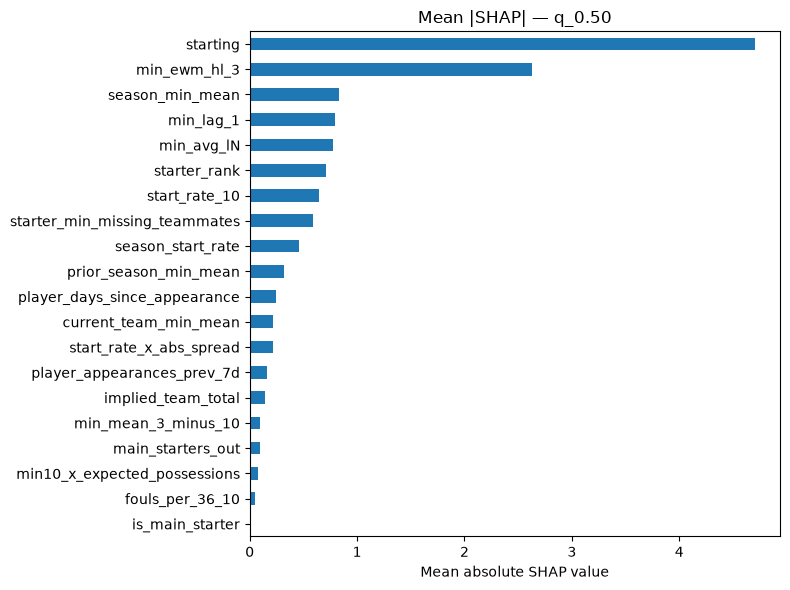

In [39]:
import shap

model = models_last["q_0.50"]
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val_last)

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
feat_imp = pd.Series(mean_abs_shap, index=MIN_FEATURES).sort_values(ascending=True)

ax = feat_imp.plot(kind="barh", figsize=(8, 6))
ax.set_title("Mean |SHAP| — q_0.50")
ax.set_xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.show()

In [40]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer
from scipy import stats as sp_stats

result = permutation_importance(
    models_last["q_0.50"],
    X_val_last,
    y_val_last,
    n_repeats=30,
    random_state=42,
    scoring=make_scorer(pinball_50),
)

pi_df = (
    pd.DataFrame({
        "feature": X_val_last.columns,
        "importance": result.importances_mean,
        "std": result.importances_std,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
pi_df.index += 1
pi_df["importance"] = pi_df["importance"].round(5)
pi_df["std"] = pi_df["std"].round(5)
pi_df["p_value"] = sp_stats.ttest_1samp(result.importances, 0.0, axis=1).pvalue.round(4)
pi_df["significant"] = pi_df["p_value"] < 0.05

print("Permutation importance (val set) — higher = more important, significant = p<0.05")
print(pi_df.to_string())

Permutation importance (val set) — higher = more important, significant = p<0.05
                          feature  importance      std  p_value  significant
1                        starting     1.08787  0.01685      0.0         True
2                    min_ewm_hl_3     0.53779  0.00674      0.0         True
3                    starter_rank     0.42538  0.00796      0.0         True
4                 season_min_mean     0.14028  0.00369      0.0         True
5                       min_lag_1     0.12964  0.00456      0.0         True
6                      min_avg_lN     0.08834  0.00296      0.0         True
7                   start_rate_10     0.07375  0.00348      0.0         True
8               season_start_rate     0.06647  0.00332      0.0         True
9   starter_min_missing_teammates     0.03931  0.00387      0.0         True
10          prior_season_min_mean     0.02400  0.00166      0.0         True
11   player_days_since_appearance     0.02199  0.00171      0.0         

In [41]:
train_mask_last = last_fold["train_mask"]
val_mask_last = last_fold["val_mask"]
X_tr_last = X.loc[train_mask_last]
X_va_last = X.loc[val_mask_last]
y_tr_last = ppm_df.loc[train_mask_last, TARGET_COL]
y_va_last = ppm_df.loc[val_mask_last, TARGET_COL]

ablation_df = run_feature_ablation(
    MIN_FEATURES, X_tr_last, y_tr_last, X_va_last, y_va_last,
    xgb_params=XGB_PARAMS,
)

Baseline pinball q50 (all features): 2.2337
                          feature  ablated_pinball  delta_pinball
1                        starting           2.3133         0.0796
2                       min_lag_1           2.2446         0.0109
3                    starter_rank           2.2434         0.0096
4         start_rate_x_abs_spread           2.2375         0.0037
5    player_days_since_appearance           2.2371         0.0033
6               season_start_rate           2.2359         0.0021
7                 season_min_mean           2.2349         0.0011
8                      min_avg_lN           2.2348         0.0011
9                    min_ewm_hl_3           2.2344         0.0007
10             implied_team_total           2.2345         0.0007
11                is_main_starter           2.2338         0.0001
12                  start_rate_10           2.2336        -0.0001
13     player_appearances_prev_7d           2.2334        -0.0003
14  starter_min_missing_teammate

In [42]:
from scipy import stats

model = models_last["q_0.50"]
_shap_expl = shap.TreeExplainer(model, model_output="raw")
_shap_vals = _shap_expl(X_val_last)
_mean_abs_shap = np.abs(_shap_vals.values).mean(axis=0)

shap_table = pd.DataFrame({
    "feature": X_val_last.columns,
    "mean_abs_shap": _mean_abs_shap,
}).assign(shap_rank=lambda d: d["mean_abs_shap"].rank(method="min", ascending=False).astype(int))

perm_table = (
    pi_df.sort_values("importance", ascending=False)
    .reset_index(drop=True)
    .rename(columns={"importance": "perm_importance", "std": "perm_importance_std"})
)
perm_table["perm_rank"] = np.arange(1, len(perm_table) + 1)
perm_table = perm_table[["feature", "perm_rank", "perm_importance", "perm_importance_std"]]

perm_pv = pd.DataFrame({
    "feature": X_val_last.columns,
    "perm_pvalue": stats.ttest_1samp(result.importances, 0.0, axis=1, nan_policy="omit").pvalue,
})

abla = ablation_df[["feature", "delta_pinball"]].rename(columns={"delta_pinball": "ablation_delta"})

feature_audit = (
    pd.DataFrame({"feature": MIN_FEATURES})
    .merge(shap_table, on="feature", how="left")
    .merge(perm_table, on="feature", how="left")
    .merge(perm_pv, on="feature", how="left")
    .merge(abla, on="feature", how="left")
)

_ms = feature_audit["mean_abs_shap"].astype(float)
_mp = feature_audit["perm_importance"].astype(float)
_max_shap = _ms.fillna(0).max()
_max_perm = _mp.fillna(0).max()
feature_audit["shap_norm"] = np.where(_max_shap > 0, _ms.fillna(0) / _max_shap, 0.0)
feature_audit["perm_norm"] = np.where(_max_perm > 0, _mp.fillna(0) / _max_perm, 0.0)
feature_audit["consensus"] = (feature_audit["shap_norm"] + feature_audit["perm_norm"]) / 2
feature_audit = feature_audit.sort_values("consensus", ascending=False).reset_index(drop=True)
feature_audit.index += 1
feature_audit["keep"] = (feature_audit["perm_pvalue"] < 0.05) & (feature_audit["ablation_delta"] > 0)

print(feature_audit.to_string())

                          feature  mean_abs_shap  shap_rank  perm_rank  perm_importance  perm_importance_std   perm_pvalue  ablation_delta  shap_norm  perm_norm  consensus   keep
1                        starting       4.703083          1          1          1.08787              0.01685  4.750403e-54          0.0796   1.000000   1.000000   1.000000   True
2                    min_ewm_hl_3       2.626928          2          2          0.53779              0.00674  1.035826e-56          0.0007   0.558554   0.494351   0.526453   True
3                    starter_rank       0.710372          6          3          0.42538              0.00796  1.138871e-51          0.0096   0.151044   0.391021   0.271032   True
4                 season_min_mean       0.829486          3          4          0.14028              0.00369  2.289450e-47          0.0011   0.176371   0.128949   0.152660   True
5                       min_lag_1       0.793372          4          5          0.12964              0.00

### Slice Analysis

In [43]:
import importlib

import models.shared.artifacts as artifact_mod

importlib.reload(artifact_mod)
from models.shared.artifacts import monotonize_quantiles

dates = pd.to_datetime(ppm_holdout["game_date"])
y_all = np.asarray(y_ho, dtype=float)
raw_q = {key: np.asarray(pred, dtype=float) for key, pred in preds_ho.items()}
model = raw_q["q_0.50"]

def slice_score(name, mask, qmap):
    mask = np.asarray(mask, dtype=bool)
    n = int(mask.sum())
    if n == 0:
        return {"slice": name, "n": 0}
    y = y_all[mask]
    qmap = {key: values[mask] for key, values in qmap.items()}
    error = y - qmap["q_0.50"]
    return {
        "slice": name,
        "n": n,
        "mae": float(np.mean(np.abs(error))),
        "bias": float(np.mean(error)),
        "p_actual_le_q50": float(np.mean(y <= qmap["q_0.50"])),
        "cov_80": interval_coverage(y, qmap["q_0.10"], qmap["q_0.90"]),
        "mean_width_80": float(np.mean(qmap["q_0.90"] - qmap["q_0.10"])),
        "wis": float(np.mean(wis_values(y, qmap))),
    }

print("1. April is late regular season, not the postseason")
holdout_season = df.loc[df["season_year"].astype("string").eq(str(HOLDOUT_SEASON))]
print(holdout_season["season_type"].astype("string").value_counts(dropna=False).to_string())
print(
    f"Holdout dates {dates.min().date()} \u2192 {dates.max().date()}. "
    "The silver store only has regular_season gamelogs, so playoff games are not in this test."
)
blocks = {
    "October\u2013February": dates < "2026-03-01",
    "March 1\u201314": (dates >= "2026-03-01") & (dates < "2026-03-15"),
    "March 15\u201331": (dates >= "2026-03-15") & (dates < "2026-04-01"),
    "April regular season": dates >= "2026-04-01",
}
calendar = pd.DataFrame([slice_score(name, mask, raw_q) for name, mask in blocks.items()])
display(calendar.round(3))
print(
    "Limitation: April's higher MAE and lower 80% coverage is the last two weeks of the "
    "regular season. It is not a postseason effect, and the model has not been tested on playoff games."
)

print("\n2. Starter and bench mean bias versus median calibration")
starting = ppm_holdout["starting"].to_numpy()
role = pd.DataFrame([
    slice_score("Confirmed starter", starting == 1, raw_q),
    slice_score("Bench", starting == 0, raw_q),
])
display(role.round(3))
for _, row in role.iterrows():
    if row["n"] == 0:
        continue
    gap = row["p_actual_le_q50"] - 0.50
    if abs(gap) <= 0.02:
        reading = "q50 is near 50%, so the mean bias is skew around a calibrated median"
    elif gap > 0:
        reading = "q50 is too high: actuals fall under the median more often than 50%"
    else:
        reading = "q50 is too low: actuals fall under the median less often than 50%"
    print(
        f"  {row['slice']}: bias {row['bias']:+.2f} min, "
        f"P(actual <= q50) {row['p_actual_le_q50']:.1%}. {reading}."
    )

print("\n3. Monotone rearrangement")
ordered_keys = sorted(raw_q, key=lambda key: float(str(key).split("_", 1)[1]))
grid = np.column_stack([raw_q[key] for key in ordered_keys])
crossed = np.any(np.diff(grid, axis=1) < 0, axis=1)
preds_ho_mono = monotonize_quantiles(raw_q)
mono_grid = np.column_stack([preds_ho_mono[key] for key in ordered_keys])
shift = pd.DataFrame([
    {
        "quantile": key,
        "mean_abs_shift": float(np.mean(np.abs(preds_ho_mono[key] - raw_q[key]))),
        "share_changed": float(np.mean(preds_ho_mono[key] != raw_q[key])),
    }
    for key in ordered_keys
])
print(
    f"Crossing before {crossed.mean():.2%} of rows; "
    f"after rearrangement {np.any(np.diff(mono_grid, axis=1) < 0, axis=1).mean():.2%}."
)
display(shift.round(4))
print("Simulate from preds_ho_mono. The saved trees stay raw; sort each row after predict.")

print("\n4. Cold-start and missing-baseline rows")
lag = ppm_holdout["min_lag_1"].to_numpy(dtype=float)
season_avg = ppm_holdout["season_min_mean"].to_numpy(dtype=float)
ewma = ppm_holdout["min_ewm_hl_10"].to_numpy(dtype=float)
cold = ~np.isfinite(lag)
season_opener = np.isfinite(lag) & ~np.isfinite(season_avg)
missing_any = cold | season_opener | ~np.isfinite(ewma)
print(
    f"Missing any baseline: {int(missing_any.sum()):,} | "
    f"no prior game (min_lag_1 missing): {int(cold.sum()):,} | "
    f"season opener with history: {int(season_opener.sum()):,}"
)

role_quantiles = {}
for role_value, role_name in ((1, "starter"), (0, "bench")):
    history = ppm_df.loc[ppm_df["starting"] == role_value, "minutes"].to_numpy(dtype=float)
    history = history[np.isfinite(history)]
    role_quantiles[role_name] = {
        key: float(np.quantile(history, float(str(key).split("_", 1)[1])))
        for key in ordered_keys
    }
fallback_q = {key: preds_ho_mono[key].copy() for key in ordered_keys}
for key in ordered_keys:
    fallback_q[key][cold & (starting == 1)] = role_quantiles["starter"][key]
    fallback_q[key][cold & (starting == 0)] = role_quantiles["bench"][key]

missing_table = pd.DataFrame([
    slice_score("Season opener, model", season_opener, raw_q),
    slice_score("No prior game, model", cold, raw_q),
    slice_score("No prior game, role fallback", cold, fallback_q),
    slice_score("Any missing baseline, model", missing_any, raw_q),
])
display(missing_table.round(3))
print(
    "Live fallback: if min_lag_1 exists, predict with the quantile model and then "
    "sort that row into increasing quantile order, even when season_min_mean is missing. "
    "If min_lag_1 is missing, do not use the tree. Use the training-pool minute quantiles "
    "for the confirmed role (starter or bench). preds_ho_live applies that rule."
)
preds_ho_live = fallback_q


1. April is late regular season, not the postseason
season_type
Regular Season    26648
Holdout dates 2025-10-21 → 2026-04-12. The silver store only has regular_season gamelogs, so playoff games are not in this test.


,slice,n,mae,bias,p_actual_le_q50,cov_80,mean_width_80,wis
0,October–February,19417,4.376,-0.028,0.500,0.804,14.037,3.013
1,March 1–14,2364,4.453,0.101,0.492,0.791,14.094,3.037
2,March 15–31,2806,4.400,-0.064,0.500,0.809,14.105,2.988
3,April regular season,2061,5.048,0.575,0.482,0.747,14.324,3.484


Limitation: April's higher MAE and lower 80% coverage is the last two weeks of the regular season. It is not a postseason effect, and the model has not been tested on playoff games.

2. Starter and bench mean bias versus median calibration


,slice,n,mae,bias,p_actual_le_q50,cov_80,mean_width_80,wis
0,Confirmed starter,12300,4.138,-0.569,0.514,0.81,13.226,2.874
1,Bench,14348,4.693,0.536,0.484,0.79,14.796,3.199


  Confirmed starter: bias -0.57 min, P(actual <= q50) 51.4%. q50 is near 50%, so the mean bias is skew around a calibrated median.
  Bench: bias +0.54 min, P(actual <= q50) 48.4%. q50 is near 50%, so the mean bias is skew around a calibrated median.

3. Monotone rearrangement
Crossing before 1.40% of rows; after rearrangement 0.00%.


,quantile,mean_abs_shift,share_changed
0,q_0.05,0.0001,0.0013
1,q_0.10,0.0004,0.0023
2,q_0.20,0.0007,0.0030
3,q_0.30,0.0010,0.0051
4,q_0.40,0.0010,0.0052
5,q_0.50,0.0009,0.0043
6,q_0.60,0.0008,0.0033
7,q_0.70,0.0008,0.0026
8,q_0.80,0.0006,0.0016
9,q_0.90,0.0004,0.0008


Simulate from preds_ho_mono. The saved trees stay raw; sort each row after predict.

4. Cold-start and missing-baseline rows
Missing any baseline: 582 | no prior game (min_lag_1 missing): 104 | season opener with history: 478


,slice,n,mae,bias,p_actual_le_q50,cov_80,mean_width_80,wis
0,"Season opener, model",478,5.208,0.788,0.477,0.755,14.965,3.621
1,"No prior game, model",104,6.152,3.081,0.442,0.779,17.061,4.145
2,"No prior game, role fallback",104,9.345,-6.079,0.769,0.712,23.154,5.653
3,"Any missing baseline, model",582,5.376,1.198,0.471,0.759,15.339,3.715


Live fallback: if min_lag_1 exists, predict with the quantile model and then sort that row into increasing quantile order, even when season_min_mean is missing. If min_lag_1 is missing, do not use the tree. Use the training-pool minute quantiles for the confirmed role (starter or bench). preds_ho_live applies that rule.


### Error Analysis

In [44]:
# Holdout misses. Score, fouls, and plus/minus are post-game context.
# They explain a miss; they were not inputs to the model.
ctx = (
    df[[
        "game_id", "player_id", "team_abbreviation", "matchup", "wl",
        "pf", "pfd", "pts", "plus_minus", "team_pts", "opp_pts",
        "abs_spread",
    ]]
    .drop_duplicates(["game_id", "player_id"])
)
team_minutes = (
    df.groupby(["game_id", "team_abbreviation"], as_index=False)["minutes"]
    .sum()
    .rename(columns={"minutes": "team_minutes"})
)

miss = ppm_holdout.reset_index(drop=True).copy()
miss["q10"] = np.asarray(preds_ho["q_0.10"], dtype=float)
miss["q50"] = np.asarray(preds_ho["q_0.50"], dtype=float)
miss["q90"] = np.asarray(preds_ho["q_0.90"], dtype=float)
miss["error"] = miss["minutes"] - miss["q50"]
miss["abs_error"] = miss["error"].abs()
miss = miss.merge(ctx, on=["game_id", "player_id"], how="left")
miss = miss.merge(team_minutes, on=["game_id", "team_abbreviation"], how="left")
miss["game_date"] = pd.to_datetime(miss["game_date"]).dt.date
miss["score"] = (
    miss["team_pts"].round().astype("Int64").astype("string")
    + "-"
    + miss["opp_pts"].round().astype("Int64").astype("string")
)
miss["margin"] = miss["team_pts"] - miss["opp_pts"]
miss["ot"] = miss["team_minutes"] >= 260
miss["band"] = (
    miss["q10"].round().astype("Int64").astype("string")
    + "–"
    + miss["q90"].round().astype("Int64").astype("string")
)

sat_early = miss["error"] <= -8
played_more = miss["error"] >= 8
blowout = miss["margin"].abs() >= 15
outside_80 = (miss["minutes"] < miss["q10"]) | (miss["minutes"] > miss["q90"])
miss["hint"] = np.select(
    [
        (miss["pf"] >= 6) & sat_early,
        (miss["pf"] >= 5) & sat_early,
        blowout & sat_early & (miss["starting"] == 1),
        blowout & played_more & (miss["starting"] == 0),
        miss["ot"] & played_more,
        (miss["starting"] == 0) & (miss["min_lag_1"] >= 20) & (miss["error"] <= -10),
        (miss["starting"] == 1) & (miss["min_lag_1"].fillna(0) < 15) & (miss["error"] >= 10),
        outside_80,
    ],
    [
        "fouled out",
        "foul trouble",
        "blowout rest",
        "garbage time",
        "overtime",
        "unexpected bench",
        "unexpected start",
        "outside 10–90",
    ],
    default="",
)

show = [
    "game_date", "player_name", "matchup", "score", "wl",
    "minutes", "q50", "error", "band", "pf", "pfd",
    "starting", "pts", "plus_minus", "margin",
    "min_lag_1", "season_min_mean", "abs_spread", "ot", "hint",
]
labels = {
    "game_date": "date",
    "player_name": "player",
    "matchup": "game",
    "minutes": "actual_min",
    "q50": "pred_q50",
    "error": "actual − q50",
    "band": "q10–q90",
    "pf": "fouls",
    "pfd": "fouls_drawn",
    "plus_minus": "+/-",
    "min_lag_1": "last_game_min",
    "season_min_mean": "season_avg",
    "abs_spread": "pregame_|spread|",
}

def show_misses(frame, title):
    view = frame[show].rename(columns=labels).round(1)
    print(title)
    display(view)

way_off = miss["abs_error"] >= 10
print(
    f"{HOLDOUT_SEASON} holdout: {int(way_off.sum()):,} / {len(miss):,} rows "
    f"missed by 10+ minutes ({way_off.mean():.1%}). "
    f"Median |error| {miss['abs_error'].median():.1f}."
)
print("actual − q50 > 0 means he played more than the median prediction.")

show_misses(
    miss.nsmallest(20, "error"),
    "\nPlayed much less than q50 (sat, foul trouble, blowout rest)",
)
show_misses(
    miss.nlargest(20, "error"),
    "\nPlayed much more than q50 (garbage time, overtime, unexpected run)",
)

biggest = pd.concat(
    [miss.nsmallest(20, "error"), miss.nlargest(20, "error")],
    ignore_index=True,
)
print("\nHints on those 40 misses")
print(biggest["hint"].replace("", "unlabeled").value_counts().to_string())

rotation = miss["q50"] >= 15
off_players = (
    miss.loc[rotation & (miss["abs_error"] >= 10)]
    .sort_values("abs_error", ascending=False)
    .groupby(["game_id", "team_abbreviation"])
    .apply(
        lambda g: ", ".join(
            f"{row.player_name} ({row.error:+.0f}, {int(row.pf)} PF)"
            for row in g.itertuples()
        ),
        include_groups=False,
    )
    .rename("players_off_by_10")
    .reset_index()
)
games = (
    miss.loc[rotation]
    .groupby(["game_id", "game_date", "team_abbreviation", "matchup", "score", "wl"], as_index=False)
    .agg(
        n_rotation=("player_id", "size"),
        n_off_10=("abs_error", lambda s: int((s >= 10).sum())),
        mean_abs_error=("abs_error", "mean"),
        margin=("margin", "mean"),
        ot=("ot", "max"),
    )
    .merge(off_players, on=["game_id", "team_abbreviation"], how="left")
    .sort_values(["n_off_10", "mean_abs_error"], ascending=False)
)
print("\nTeam-games where the most rotation players (q50 ≥ 15) missed by 10+ minutes")
display(
    games.head(15)[
        [
            "game_date", "matchup", "score", "wl", "margin", "ot",
            "n_rotation", "n_off_10", "mean_abs_error", "players_off_by_10",
        ]
    ].rename(columns={"game_date": "date", "matchup": "game"}).round(1)
)

2025-26 holdout: 2,252 / 26,648 rows missed by 10+ minutes (8.5%). Median |error| 3.5.
actual − q50 > 0 means he played more than the median prediction.

Played much less than q50 (sat, foul trouble, blowout rest)


,date,player,game,score,wl,actual_min,pred_q50,actual − q50,q10–q90,fouls,fouls_drawn,starting,pts,+/-,margin,last_game_min,season_avg,pregame_|spread|,ot,hint
11244,2026-01-03,Alperen Sengun,HOU @ DAL,104-110,L,1.1,34.4,-33.3,27–39,0,0,1,0,0,-6,33.7,35.6,8.0,False,outside 10–90
26387,2026-04-12,Mikal Bridges,NYK vs. CHA,96-110,L,0.4,32.8,-32.5,26–38,1,0,1,0,0,-14,33.1,33.2,14.5,False,outside 10–90
831,2025-10-26,Anthony Edwards,MIN vs. IND,114-110,W,3.1,34.8,-31.7,29–40,0,0,1,5,8,4,34.7,37.0,12.0,False,outside 10–90
4018,2025-11-14,OG Anunoby,NYK vs. MIA,140-132,W,5.1,35.5,-30.4,29–40,1,0,1,2,1,8,33.9,33.5,6.5,False,outside 10–90
18402,2026-02-22,Deni Avdija,POR @ PHX,92-77,W,1.0,31.2,-30.2,25–37,0,0,1,0,0,15,30.4,34.2,3.5,False,blowout rest
18732,2026-02-24,Jalen Johnson,ATL vs. WAS,119-98,W,5.6,35.2,-29.5,28–40,1,1,1,5,2,21,37.8,35.8,12.0,False,blowout rest
12983,2026-01-14,Jalen Brunson,NYK @ SAC,101-112,L,5.0,34.4,-29.5,28–39,0,0,1,4,-8,-11,36.6,35.3,11.0,False,outside 10–90
1319,2025-10-29,Anthony Davis,DAL vs. IND,107-105,W,6.6,35.8,-29.2,29–40,0,0,1,4,-3,2,38.1,35.7,6.0,False,outside 10–90
5021,2025-11-21,Aaron Gordon,DEN @ HOU,112-109,W,3.4,32.4,-29.1,25–37,0,1,1,1,4,3,32.4,30.4,3.0,False,outside 10–90
13482,2026-01-17,Naz Reid,MIN @ SAS,123-126,L,5.0,33.6,-28.6,26–39,0,0,1,0,0,-3,32.0,26.7,5.0,False,outside 10–90



Played much more than q50 (garbage time, overtime, unexpected run)


,date,player,game,score,wl,actual_min,pred_q50,actual − q50,q10–q90,fouls,fouls_drawn,starting,pts,+/-,margin,last_game_min,season_avg,pregame_|spread|,ot,hint
22887,2026-03-21,Kennedy Chandler,UTA vs. PHI,116-126,L,37.2,6.5,30.7,2–20,2,4,0,19,-4,-10,2.6,NaN,5.5,False,outside 10–90
7346,2025-12-05,Ethan Thompson,IND @ CHI,120-105,W,34.3,5.8,28.5,1–16,4,1,0,11,25,15,3.2,5.1,4.5,False,garbage time
21632,2026-03-13,Bez Mbeng,UTA @ POR,114-124,L,33.8,5.7,28.1,1–20,1,1,0,4,-28,-10,NaN,NaN,15.5,False,outside 10–90
21046,2026-03-10,Ron Harper Jr.,BOS @ SAS,116-125,L,33.2,6.2,27.0,1–17,0,1,0,22,-12,-9,4.3,10.7,3.5,False,outside 10–90
730,2025-10-25,RayJ Dennis,IND @ MEM,103-128,L,27.9,2.3,25.5,0–11,5,3,0,7,-8,-25,28.9,NaN,2.0,False,garbage time
26466,2026-04-12,Dalano Banton,BOS vs. ORL,113-108,W,36.5,11.2,25.3,3–21,2,2,0,2,3,5,6.0,5.0,13.5,False,outside 10–90
5318,2025-11-22,Andre Jackson Jr.,MIL vs. DET,116-129,L,28.9,3.8,25.1,1–13,3,2,0,6,-3,-13,3.6,3.7,8.0,False,outside 10–90
17980,2026-02-19,Kadary Richmond,WAS vs. IND,112-105,W,29.4,4.5,25.0,1–15,1,3,0,13,8,7,6.1,6.1,2.0,False,outside 10–90
17910,2026-02-19,Alondes Williams,WAS vs. IND,112-105,W,27.7,2.8,24.9,1–14,1,2,0,6,12,7,3.7,NaN,2.0,False,outside 10–90
1328,2025-10-29,Dwight Powell,DAL vs. IND,107-105,W,29.4,4.5,24.9,1–13,4,8,0,18,12,2,2.2,3.4,6.0,False,outside 10–90



Hints on those 40 misses
hint
outside 10–90    26
garbage time      6
blowout rest      5
overtime          3

Team-games where the most rotation players (q50 ≥ 15) missed by 10+ minutes


,date,game,score,wl,margin,ot,n_rotation,n_off_10,mean_abs_error,players_off_by_10
2385,2026-04-12,DAL vs. CHI,149-128,W,21.0,False,8,7,15.2,"Cooper Flagg (-25, 1 PF), Moussa Cisse (+22, 4..."
2265,2026-04-05,WAS @ BKN,115-121,L,-6.0,False,8,6,13.0,"Sharife Cooper (-18, 0 PF), Jamir Watkins (+18..."
1774,2026-03-03,PHI vs. SAS,91-131,L,-40.0,False,7,6,12.7,"Andre Drummond (-20, 3 PF), VJ Edgecombe (-17,..."
1621,2026-02-21,PHX vs. ORL,113-110,W,3.0,True,10,6,11.8,"Dillon Brooks (-24, 1 PF), Royce O'Neale (+17,..."
238,2025-10-27,PHX @ UTA,134-138,L,-4.0,True,8,6,11.2,"Royce O'Neale (+15, 5 PF), Nigel Hayes-Davis (..."
2298,2026-04-07,BKN vs. MIL,96-90,W,6.0,False,9,6,9.5,"Chaney Johnson (-13, 2 PF), Nolan Traore (-13,..."
8,2025-10-23,IND vs. OKC,135-141,L,-6.0,True,6,5,12.7,"Obi Toppin (+23, 3 PF), Isaiah Jackson (-15, 4..."
607,2025-11-30,PHI vs. ATL,134-142,L,-8.0,True,9,5,11.1,"Dominick Barlow (+19, 2 PF), Quentin Grimes (+..."
1465,2026-02-05,WAS @ DET,126-117,W,9.0,False,8,5,10.7,"Sharife Cooper (+17, 3 PF), Justin Champagnie ..."
1450,2026-02-04,DEN @ NYK,127-134,L,-7.0,True,9,5,10.1,"Spencer Jones (-18, 1 PF), Christian Braun (+1..."


### Save Exploratory Artifact

In [45]:
from datetime import datetime, timezone

def _iso_date(value):
    return pd.Timestamp(value).date().isoformat()

metadata = {
    "created_at": datetime.now(timezone.utc).isoformat(),
    "status": "exploratory",
    "model_name": "quantile_xgboost",
    "artifact_stem": ARTIFACT_STEM,
    "features": list(MIN_FEATURES),
    "label": TARGET_COL,
    "label_rule": "minutes > 0",
    "quantiles": list(QUANTILES),
    "point_forecast": 0.50,
    "interval": [0.10, 0.90],
    "params": {
        key: XGB_PARAMS[key]
        for key in (
            "objective",
            "n_estimators",
            "max_depth",
            "learning_rate",
            "subsample",
            "colsample_bytree",
            "reg_alpha",
            "reg_lambda",
            "min_child_weight",
            "early_stopping_rounds",
            "random_state",
        )
    },
    "seed": SEED,
    "train_range": [
        _iso_date(ppm_df["game_date"].min()),
        _iso_date(ppm_df["game_date"].max()),
    ],
    "holdout_season": HOLDOUT_SEASON,
    "holdout_range": [
        _iso_date(ppm_holdout["game_date"].min()),
        _iso_date(ppm_holdout["game_date"].max()),
    ],
    "primary_metric": "q50 pinball",
    "test_metrics": {
        "n": ho_metrics["n"],
        "pinball_q50": ho_metrics["pinball"],
        "coverage_80": ho_metrics.get("coverage_80pct"),
        "coverage_90": ho_metrics.get("coverage_90pct"),
        "walk_forward_pinball_q50": float(
            np.mean([row["pinball"] for row in wf_results])
        ),
    },
}
display(metadata)

{'created_at': '2026-10-03T00:22:03.353205+00:00',
 'status': 'exploratory',
 'model_name': 'quantile_xgboost',
 'artifact_stem': 'min_nba_model',
 'features': ['starting',
  'min_ewm_hl_3',
  'min_lag_1',
  'season_min_mean',
  'current_team_min_mean',
  'min10_x_expected_possessions',
  'season_start_rate',
  'start_rate_10',
  'player_days_since_appearance',
  'player_appearances_prev_7d',
  'prior_season_min_mean',
  'start_rate_x_abs_spread',
  'implied_team_total',
  'min_mean_3_minus_10',
  'starter_min_missing_teammates',
  'main_starters_out',
  'min_avg_lN',
  'starter_rank',
  'is_main_starter',
  'fouls_per_36_10'],
 'label': 'minutes',
 'label_rule': 'minutes > 0',
 'quantiles': [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95],
 'point_forecast': 0.5,
 'interval': [0.1, 0.9],
 'params': {'objective': 'reg:quantileerror',
  'n_estimators': 1198,
  'max_depth': 4,
  'learning_rate': 0.10831429032170246,
  'subsample': 0.7978199709619458,
  'colsample_bytree': 0.8074

In [46]:
import importlib
import models.shared.artifacts as artifact_mod

importlib.reload(artifact_mod)
save_model_bundle = artifact_mod.save_model_bundle
load_model_bundle = artifact_mod.load_model_bundle

save_path = save_model_bundle(
    models_ho,
    train_df=ppm_df,
    holdout_df=ppm_holdout,
    wf_results=wf_results,
    ho_metrics=ho_metrics,
    features=MIN_FEATURES,
    artifact_stem=ARTIFACT_STEM,
    metadata=metadata,
)

bundle = load_model_bundle(save_path)
models_loaded = bundle["quantile_models"]
feature_names = bundle["feature_names"]

assert list(X_ho.columns) == list(feature_names)
quantile_keys = sorted(
    models_loaded,
    key=lambda key: float(str(key).split("_", 1)[1]),
)
loaded_preds = pd.DataFrame({
    key: models_loaded[key].predict(X_ho) for key in quantile_keys
})
print("Saved quantiles:", ", ".join(loaded_preds.columns))
print(
    f"Loaded model pinball q50 (holdout): "
    f"{pinball_loss(y_ho, loaded_preds['q_0.50'], 0.50):.3f}"
)
print(
    f"Loaded model 80% coverage (holdout): "
    f"{interval_coverage(y_ho, loaded_preds['q_0.10'], loaded_preds['q_0.90']):.1%}"
)
print(f"Trained on data up to      : {bundle['train_end'].date()}")
print(f"Holdout through            : {bundle['val_end'].date()}")

loaded_preds.head(3)


Saved to /Users/alexgonzalez/Documents/nba_quant/models/saved_models/min_nba_model_2026-04-12.joblib
Loaded /Users/alexgonzalez/Documents/nba_quant/models/saved_models/min_nba_model_2026-04-12.joblib
Saved quantiles: q_0.05, q_0.10, q_0.20, q_0.30, q_0.40, q_0.50, q_0.60, q_0.70, q_0.80, q_0.90, q_0.95
Loaded model pinball q50 (holdout): 2.219
Loaded model 80% coverage (holdout): 79.9%
Trained on data up to      : 2025-04-13
Holdout through            : 2026-04-12


,q_0.05,q_0.10,q_0.20,q_0.30,q_0.40,q_0.50,q_0.60,q_0.70,q_0.80,q_0.90,q_0.95
0,24.622524,27.547163,29.923061,31.273298,33.330238,34.096642,35.242470,36.328278,37.020912,38.534512,39.624027
1,7.901133,11.223391,14.413390,16.395559,18.429537,20.545048,22.420391,23.444134,24.920729,27.262312,29.719973
2,24.778194,27.071188,29.753759,31.110239,32.246181,33.457325,34.575417,35.560345,36.643372,37.971550,38.904877


### Conclusion
**- Selected Model:** Quantile XGBoost (`reg:quantileerror`) at all 11 levels, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, and 0.95, with the locked Optuna params (depth 4, 1,198 trees). Saved at `models/saved_models/min_nba_model_2026-04-12.joblib`. Quantile LightGBM (`objective='quantile'`, 1,332 trees, 39 leaves, depth 8) is scored on the same 11 levels and is not the saved bundle.

**- Primary test result:** 2025-26 blind holdout, 26,648 player-games, scored once. q50 pinball is 2.219 for XGBoost and 2.217 for LightGBM (XGBoost minus LightGBM +0.002). Across the other ten levels the pinball gap stays inside ±0.003. 80% coverage is 79.9% for XGBoost and 79.4% for LightGBM. 90% coverage is 89.6% and 89.2%. On the 26,066 paired rows, MAE is 4.414 (LightGBM), 4.416 (XGBoost), 4.933 (EWMA), 5.298 (season-to-date), and 5.766 (last game). XGBoost minus EWMA MAE is −0.517 (CI −0.584 to −0.459). XGBoost minus LightGBM MAE is +0.003 (CI −0.002 to +0.007). WIS on the 11 knots is 3.049 versus 3.048. Quantile crossing, any adjacent pair, is 1.40% (XGBoost, 372 rows) and 0.32% (LightGBM). Mean 80% width is 14.07 minutes for XGBoost and 13.97 for LightGBM; the 90% widths are 18.22 and 18.07. Walk-forward q50 pinball is 2.228 for XGBoost and 2.226 for LightGBM. Walk-forward 80% coverage is 78.5% and 78.0%. The XGBoost holdout gap is −0.010.

**- Operating point:** None for serving. This notebook is exploration only. The point forecast is q50. The uncertainty band is q10–q90. The saved XGBoost trees stay raw. Sort the 11 knots before a probability is read.

**- Slice findings:** Minute tiers use XGBoost predicted q50, so both models are scored on the same games.
- Starters (n=12,300): XGBoost MAE 4.14, bias −0.57, 80% coverage 81.0%. LightGBM MAE 4.14, bias −0.54, 80% coverage 80.6%.
- Bench (n=14,348): XGBoost MAE 4.69, bias +0.54, 80% coverage 79.0%. LightGBM MAE 4.69, bias +0.50, 80% coverage 78.4%.
- MAE falls as predicted minutes rise. Under 15 (n=6,310) both models are biased low: XGBoost bias +0.98, LightGBM +0.90. At 31+ (n=5,613) MAE is 3.82 for both, with bias −0.83 (XGBoost) and −0.77 (LightGBM).
- October through March stays near MAE 4.2–4.6 and about 80% coverage for both. April regular season (n=2,061, through 2026-04-12) is MAE 5.05 for XGBoost and 5.05 for LightGBM, bias +0.58 and +0.62, 80% coverage 74.7% and 74.0%. That is the last two weeks of the regular season.
- Misses of 10+ minutes: 2,252 rows (8.5%) for XGBoost and 2,234 (8.4%) for LightGBM. The large misses are early exits of high-minute starters, blowout rest, garbage time, and overtime, often several rotation players in the same game.

**- Known limitations:** The label is `minutes` > 0, so DNPs are out. Pregame features cannot see an in-game exit, and the 80% band is about 14 minutes wide. On the last walk-forward fold, dropping `starting` raises q50 pinball by 0.08. `starter_rank` and `min_lag_1` move it by about 0.01. Permutation importance is led by `starting`, `min_ewm_hl_3`, and `starter_rank`. `fouls_per_36_10`, `starter_min_missing_teammates`, and `main_starters_out` do not help that fold. Both holdout fits early-stop on the last 10% of the train pool (15,007 rows). Walk-forward early-stops on the rows it scores. The silver store is regular season only, so playoffs are untested. On the 104 rows with no prior game, the role-quantile fallback is worse than the XGBoost tree (MAE 9.3 vs 6.2).

**- Recommendation:** Keep the saved XGBoost as the exploratory minutes model. It beats EWMA by a margin the date-clustered interval does not contain. LightGBM matches it on the 11-level holdout: the MAE interval contains zero, q50 pinball differs by 0.002, and WIS differs by 0.001. The walk-forward is the same story, 2.228 versus 2.226. XGBoost stays the saved model because 80% coverage is closer to the target on the holdout (79.9% versus 79.4%) and on the walk-forward (78.5% versus 78.0%). Crossing is higher for XGBoost on this grid (1.40% versus 0.32%); sort the knots before the band is used. Leave both out of production props for now: about one in twelve player-games is off by 10 minutes.

### Next Steps
- Cut the feature list on the walk-forward folds. `starting`, recent minutes, and `starter_rank` carry the model. `fouls_per_36_10` and the teammate-absence columns did not.
- Split availability from minutes-given-played. This model never sees a zero.
- Revisit the no-prior-game rule. The training-pool role quantiles lost to the tree on these 104 rows.
- Score playoffs as their own holdout once those gamelogs are in the silver store.
- Sort the 11 quantiles after predict before any simulation uses the band.




- Score LightGBM on the walk-forward folds before treating it as a replacement. A second 2025-26 score is a new locked run, not a tuning loop.
